# Caso 01 — Transferencia de Calor en una Partícula de Carbonizado
## Reactor de Lecho Fluidizado * Gas: N₂ * Método: Euler hacia adelante

---

**Universidad Nacional de Colombia — Sede Bogotá**  
Facultad de Ingeniería | Dpto. Ingeniería Mecánica y Mecatrónica  
Modelación Matemática — Taller 01

| Autor | Correo | CC |
|-------|--------|----|
| Nicolás F. Godoy | ngodoya@unal.edu.co | 1013113408 |
| Juan Escobar | jsescobarp@unal.edu.co | 1032453966 |
| Oscar G. Reyes A. | ogreyesa@unal.edu.co | 1018475392 |

---
### Contexto
Durante un experimento de pirólisis en el reactor de lecho fluidizado del laboratorio, un error en la
ubicación de las termocuplas de control provocó temperaturas más altas de lo esperado dentro del reactor.
El laboratorio necesita determinar:
### Descripción del Método Numérico

Se utiliza el método de **Euler hacia adelante (Forward Euler)**, el esquema explícito de primer orden más simple para integrar EDOs:

$$\mathbf{y}^{n+1} = \mathbf{y}^{n} + \Delta t \cdot f(t^n,\, \mathbf{y}^n)$$

donde $\mathbf{y} = [z,\, v_p,\, T_p]^T$ es el vector de estado.  
El **error de truncamiento local** es $\mathcal{O}(\Delta t^2)$ y el **error global** es $\mathcal{O}(\Delta t)$.

Se implementa un análisis de convergencia variando $\Delta t$ para cuantificar este error.
## Contenido del Notebook (Para el Caso 01)

| Sección | Descripción |
|---------|-------------|
|**Caso 01**|Reactor de Lecho Fluidizado|
| **0** | Librerias |
| **1** | Fundamentos teóricos y suposiciones |
| **2** | Parámetros físicos y geometría del reactor |
| **3** | Propiedades termofísicas del N₂ |
| **4** | Correlaciones de Arrastre y Transferencia de Calor |
| **5** | Sistema de EDOs y Euler |
| **6** | Resultados principales (caso base) |
| **7** | Validación con datos de referencia |
| **8** | Resultados y Visualización |
| **9** | Análisis de Error Numérico (Convergencia del esquema de integración explicito de primer orden) |
| **10** | Análisis de sensibilidad  |
| **11** | Resumen y conclusiones |
|**Caso 02**|Modelo de Tráfico|
| **12** | Variables, metricas y vector de estado |
| **13** | Parametros del sistema |
| **14** | Reduccion de arrastre por platooning (Modelo A vs B) |
| **15** | Modelo de viento: oscilatorio + rafagas |
| **16** | Control proporcional, resistencia y frenado de emergencia |
| **17** | Simulador (Euler Forward) y calculo de metricas |
| **18** | Ejecucion: Modelo A vs Modelo B |
| **19** | Resultados: evolucion del headway |
| **20** | Resultados: retrato de fase (estabilidad de cadena) |
| **21** | Resultados: potencia y energia acumulada |
| **22** | Conclusiones y Resumen de Seguridad |

---
## 0 — Librerías

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family':     'DejaVu Sans',
    'font.size':       11,
    'axes.titlesize':  13,
    'axes.labelsize':  12,
    'axes.grid':       True,
    'grid.alpha':      0.35,
    'grid.linestyle':  '--',
    'lines.linewidth': 2.0,
    'figure.dpi':      120,
})

## 1. Suposiciónes y Teoría

### 1.1 Descripción del sistema

Se modela el **transporte unidimensional** de una partícula esférica de carbonizado en un reactor de lecho
fluidizado de sección transversal circular variable. El gas de fluidización es **nitrógeno (N₂)** que
arrastra la partícula hacia arriba desde la entrada (z = 0.10 m) hasta la salida (z = 1.12 m).

### 1.2 Volumen de control

Se adopta la **partícula de carbonizado** como volumen de control lagrangiano:
- Entradas/salidas de energía: **convección** desde el gas hacia la partícula.
- Fuerzas actuantes: **arrastre (drag)**, **gravedad** y **flotabilidad (buoyancy)**.

### 1.3 Suposiciones del modelo

| # | Suposición | Justificación |
|---|-----------|---------------|
| 1 | Partícula esférica de masa constante | El carbonizado ya está formado; no hay reacción durante el transporte |
| 2 | Temperatura uniforme en la partícula | Número de Biot $Bi = h\,d_p/(6\,k_p) \ll 1$ (partícula pequeña, $d_p=150\,\mu$m) |
| 3 | Convección dominante; radiación despreciable | Flujo rápido y partícula pequeña; $h_{rad} \ll h_{conv}$ |
| 4 | Reactor adiabático respecto al entorno | Simplificación estándar para modelado de primer orden |
| 5 | Partícula aislada (sin interacciones) | Dilución alta del lecho en la zona de análisis |
| 6 | Flujo incompresible (Ma < 0.3) | Velocidades del gas del orden de 1–2 m/s a alta temperatura |
| 7 | Flujo másico conservado (estado estacionario del gas) | El gas está en régimen estacionario; solo la partícula es transitoria |


---
## 2 — Parámetros del Sistema

Todos los valores se ingresan en unidades SI. Las conversiones están explícitas en el código.

In [2]:
# SECCIÓN 2: Librerías, constantes y parámetros del sistema
#  CONSTANTES FÍSICAS
P_atm  = 101_325.0   # Presión                    [Pa]
R_univ = 8.314       # Cte. universal gases        [J/(mol*K)]
M_N2   = 0.028_013   # Masa molar N2               [kg/mol]
g_grav = 9.81        # Aceleración gravitacional   [m/s^2]

#  PROPIEDADES DE LA PARTÍCULA DE CARBONIZADO
d_p   = 150e-6       # Diámetro           [m]  (150 um -> SI)
rho_p = 810.0        # Densidad           [kg/m^3]
cp_p  = 1520.0       # Calor específico   [J/(kg*K)]  (Mendoza, 2016)

# Volumen y masa (esfera)
V_p = (np.pi / 6.0) * d_p**3    # [m^3]
m_p = rho_p * V_p                # [kg]
print(f'  Volumen partícula : {V_p:.4e} m^3')
print(f'  Masa partícula    : {m_p:.4e} kg')

#  FLUJO VOLUMÉTRICO (conversión explícita lpm -> m^3/s)
Q_lpm   = 230.5
Q_m3s   = Q_lpm * (1.0/1000.0) * (1.0/60.0)   # m^3/s
T_Q_ref = 550.0 + 273.15                        # K (condición del flujo)
print(f'\n  Q = {Q_lpm} lpm = {Q_m3s:.6e} m^3/s  @ {T_Q_ref:.2f} K')

#  GEOMETRÍA DEL REACTOR
D_inf = 0.067        # Diámetro inferior  [m]
D_sup = 0.081        # Diámetro superior  [m]
L_r   = 1.12         # Altura total       [m]

def D_reactor(z):
    """Diámetro interno en z [m], variación lineal."""
    return D_inf + (D_sup - D_inf) / L_r * z

def A_reactor(z):
    """Área de sección transversal en z [m^2]."""
    return np.pi / 4.0 * D_reactor(z)**2

#  PERFIL DE TEMPERATURA DEL GAS
#  PT1=550°C @ z=0.10m  |  PT2=700°C @ z=0.22m
#  PT3=1000°C @ z=0.78m |  PT4=850°C @ z=1.12m
z_pts = np.array([0.10,  0.22,  0.78,  1.12])           # [m]
T_pts = np.array([550.0, 700.0, 1000.0, 850.0]) + 273.15 # [K]

def T_gas_K(z):
    """Temperatura local del gas en z [K] — interpolación lineal por tramos."""
    z_c = np.clip(z, z_pts[0], z_pts[-1])
    return float(np.interp(z_c, z_pts, T_pts))
#def T_gas_K(z):
    #return 823  # probar constante la temperatura, debería de bajar la tempertura
#  FLUJO MÁSICO (conservado, evaluado en condición ref)
rho_ref = (P_atm * M_N2) / (R_univ * T_Q_ref)   # densidad N2 @ T_ref
mdot    = rho_ref * Q_m3s                         # [kg/s]
print(f'\n  rho_N2(T_ref) = {rho_ref:.5f} kg/m^3')
print(f'  mdot          = {mdot:.6e} kg/s')

def v_gas(z):
    """Velocidad superficial del gas en z [m/s]."""
    Tg = T_gas_K(z)
    rg = (P_atm * M_N2) / (R_univ * Tg)
    return mdot / (rg * A_reactor(z))

print('\n  Velocidad del gas en puntos de termocupla:')
print(f'  {"Punto":<6} {"z [m]":<8} {"T_g [°C]":<12} {"v_g [m/s]"}')
print('  ' + '-'*38)
for i, (zi, Ti) in enumerate(zip(z_pts, T_pts)):
    print(f'  PT{i+1:<4} {zi:<8.2f} {Ti-273.15:<12.1f} {v_gas(zi):.4f}')

  Volumen partícula : 1.7671e-12 m^3
  Masa partícula    : 1.4314e-09 kg

  Q = 230.5 lpm = 3.841667e-03 m^3/s  @ 823.15 K

  rho_N2(T_ref) = 0.41475 kg/m^3
  mdot          = 1.593334e-03 kg/s

  Velocidad del gas en puntos de termocupla:
  Punto  z [m]    T_g [°C]     v_g [m/s]
  --------------------------------------
  PT1    0.10     550.0        1.0501
  PT2    0.22     700.0        1.1886
  PT3    0.78     1000.0       1.2843
  PT4    1.12     850.0        1.0172


---
## 3 — Propiedades Termofísicas del N₂

| Propiedad | Modelo | Referencia |
|-----------|--------|------------|
| $\rho_g$ | Gas ideal: $\rho_g = PM/(RT)$ | Termodinámica clásica |
| $\mu_g$ | Sutherland: $\mu_0\left(\frac{T_0+C}{T+C}\right)\left(\frac{T}{T_0}\right)^{3/2}$, $C=111\,\text{K}$ | Mendoza (2016) |
| $Cp_g$ | Polinomio NASA: $\frac{R}{M}(a_0 + a_1T + a_2T^2 + a_3T^3 + a_4T^4)$ | Mendoza (2016) |
| $k_g$ | Polinomio: $b_0 + b_1T + b_2T^2 + b_3T^3$ | Mendoza (2016) |

In [3]:
# Coeficientes polinómicos (Mendoza, 2016)
a_cp = [3.539, -0.261e-3, 0.007e-5, 0.157e-8, -0.099e-11]  # Cp
b_kg = [0.392e-3, 9.816e-5, -5.067e-8, 1.504e-11]           # k_g

def props_N2(T):
    """
    Propiedades termofísicas del N2 a T [K].
    Retorna: rho_g, mu_g, cp_g, k_g
    """
    rho_g = (P_atm * M_N2) / (R_univ * T)
    mu_g  = 1.781e-5 * ((273.15 + 111.0)/(T + 111.0)) * (T/273.15)**1.5
    T2, T3, T4 = T**2, T**3, T**4
    cp_g  = (R_univ/M_N2)*(a_cp[0] + a_cp[1]*T + a_cp[2]*T2 +
                            a_cp[3]*T3 + a_cp[4]*T4)
    k_g   = b_kg[0] + b_kg[1]*T + b_kg[2]*T2 + b_kg[3]*T3
    return rho_g, mu_g, cp_g, k_g

# ── Tabla de propiedades en los 4 puntos ────────────────────────
print('='*90)
print(f'{"TABLA 1 — PROPIEDADES TERMOFÍSICAS DEL N2":^80}')
print('='*90)
print(f'{"Punto":<6} | {"T (K)":<8} | {"rho_g (kg/m3)":<12} | {"mu_g (Pa*s)":<12} | {"Cp (J/kg*K)":<12} | {"kg (W/m*K)":<12} | {"vg [m/s]":<10}')
print('-'*90)
for i, (zi, Ti) in enumerate(zip(z_pts, T_pts)):
    rg, mg, cg, kg = props_N2(Ti)
    vg = v_gas(zi)
    print(f'PT{i+1:<4} | {Ti:<8.2f} | {rg:<13.5f} | {mg:<12.4e} | '
          f'{cg:<12.2f} | {kg:<12.5f} | {vg:.5f}')
print('='*90)

                   TABLA 1 — PROPIEDADES TERMOFÍSICAS DEL N2                    
Punto  | T (K)    | rho_g (kg/m3) | mu_g (Pa*s)  | Cp (J/kg*K)  | kg (W/m*K)   | vg [m/s]  
------------------------------------------------------------------------------------------
PT1    | 823.15   | 0.41475       | 3.8315e-05   | 1125.65      | 0.05525      | 1.05009
PT2    | 973.15   | 0.35082       | 4.2437e-05   | 1160.55      | 0.06179      | 1.18862
PT3    | 1273.15  | 0.26816       | 4.9739e-05   | 1175.01      | 0.07427      | 1.28432
PT4    | 1123.15  | 0.30397       | 4.6222e-05   | 1182.17      | 0.06803      | 1.01723


---
## 4 — Correlaciones de Arrastre y Transferencia de Calor

### Coeficiente de arrastre — Almedeij (2008)

### Número de Nusselt — Ranz-Marshall
$$Nu = 2 + 0.6\, Re_p^{1/2}\, Pr^{1/3}$$

### Tabla de parámetros adimensionales

            TABLA 2 — PARÁMETROS DE INTERACCIÓN Y TRANSPORTE            
Punto  | T[K]      | Re_p       | Pr        | Nu        | h[W/m2K]     | CD        
----------------------------------------------------------------------------------
PT1    | 823.15    | 1.7051     | 0.7806    | 2.7214    | 1002.35      | 15.445170
PT2    | 973.15    | 1.4739     | 0.7970    | 2.6754    | 1102.11      | 17.404310
PT3    | 1273.15   | 1.0386     | 0.7869    | 2.5645    | 1269.79      | 23.718649
PT4    | 1123.15   | 1.0034     | 0.8032    | 2.5587    | 1160.46      | 24.488952


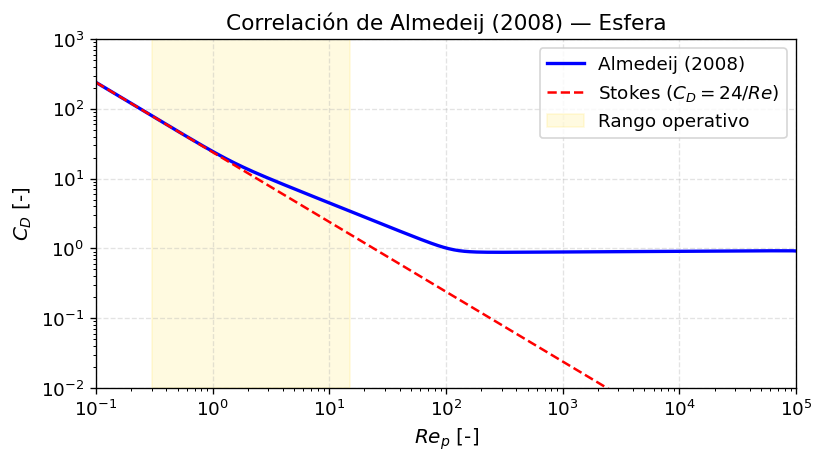

In [4]:
def cd_almedeij(Re):
    """Coeficiente de arrastre — Almedeij (2008). Re: Reynolds partícula."""
    Re = max(Re, 1e-10)
    n  = 10
    phi1 = ((24/Re)**n + (21*Re**-0.67)**n +
             (4*Re**-0.33)**n + 0.4**n)
    inv2 = (0.148*Re**0.11)**(-n) + 0.5**(-n)
    phi2 = inv2**(-1.0/n) if inv2 > 0 else 0.0
    phi3 = (1.57e8 * Re**(-1.625))**n
    inv4 = (6e-17 * Re**2.63)**(-n) + 0.2**(-n)
    phi4 = inv4**(-1.0/n) if inv4 > 0 else 0.0
    return (1.0/((phi1+phi2)**(-1)+phi3**(-1)) + phi4)**(1.0/n)

def nusselt_ranz_marshall(Re, Pr):
    """Número de Nusselt — correlación Ranz-Marshall."""
    return 2.0 + 0.6 * max(Re, 0.0)**0.5 * max(Pr, 0.0)**(1.0/3.0)

# ── Tabla de parámetros en los 4 puntos (condición inicial: vp=0) ─
print('='*82)
print(f'{"TABLA 2 — PARÁMETROS DE INTERACCIÓN Y TRANSPORTE":^72}')
print('='*82)
print(f'{"Punto":<6} | {"T[K]":<9} | {"Re_p":<10} | {"Pr":<9} | '
      f'{"Nu":<9} | {"h[W/m2K]":<12} | {"CD":<10}')
print('-'*82)
for i, (zi, Ti) in enumerate(zip(z_pts, T_pts)):
    rg, mg, cg, kg = props_N2(Ti)
    vg  = v_gas(zi)
    Re  = rg * abs(vg) * d_p / mg
    Pr  = mg * cg / kg
    Nu  = nusselt_ranz_marshall(Re, Pr)
    h_v = Nu * kg / d_p
    CD  = cd_almedeij(Re)
    print(f'PT{i+1:<4} | {Ti:<9.2f} | {Re:<10.4f} | {Pr:<9.4f} | '
          f'{Nu:<9.4f} | {h_v:<12.2f} | {CD:.6f}')
print('='*82)

# ── Curva CD vs Re ───────────────────────────────────────────────
Re_v = np.logspace(-1, 5, 400)
CD_v = np.array([cd_almedeij(r) for r in Re_v])

fig, ax = plt.subplots(figsize=(7, 4))
ax.loglog(Re_v, CD_v,    'b-',  lw=2, label='Almedeij (2008)')
ax.loglog(Re_v, 24/Re_v, 'r--', lw=1.5, label='Stokes ($C_D=24/Re$)')
ax.set_xlabel('$Re_p$ [-]')
ax.set_ylabel('$C_D$ [-]')
ax.set_title('Correlación de Almedeij (2008) — Esfera')
ax.axvspan(0.3, 15, alpha=0.12, color='gold', label='Rango operativo')
ax.set_xlim([0.1,1e5]); ax.set_ylim([1e-2,1e3])
ax.legend()
plt.tight_layout()
plt.savefig('01_fig_CD_Almedeij.png', dpi=150, bbox_inches='tight')


---
## 5 — Sistema de EDOs y Euler
### Vector de estado
$$ \mathbf{y} = [z,\; v_p,\; T_p]^T $$
### Sistema acoplado

$$\frac{dz}{dt} = v_p \tag{1}$$

$$\frac{dv_p}{dt} = \frac{3\,\rho_g\,C_D}{4\,\rho_p\,d_p}(v_g-v_p)|v_g-v_p| - g\left(1-\frac{\rho_g}{\rho_p}\right) \tag{2}$$

$$\frac{dT_p}{dt} = \frac{6\,h}{\rho_p\,c_P\,d_p}(T_g(z)-T_p) \tag{3}$$

### Euler Forward

$$z^{n+1} = z^n + \Delta t\, v_p^n$$
$$v_p^{n+1} = v_p^n + \Delta t\, f_v(z^n, v_p^n)$$
$$T_p^{n+1} = T_p^n + \Delta t\, f_T(z^n, T_p^n)$$

In [5]:
def derivadas(z, vp, Tp, cp_var=None, mdot_var=None):
    """
    Evalúa las 3 derivadas del sistema en el estado (z, vp, Tp).
    Parámetros opcionales para análisis de sensibilidad:
      cp_var   : calor específico partícula [J/(kg*K)]
      mdot_var : flujo másico del gas [kg/s]

    Retorna: dz_dt, dvp_dt, dTp_dt
    """
    if cp_var   is None: cp_var   = cp_p
    if mdot_var is None: mdot_var = mdot

    z_c = np.clip(z, z_pts[0], z_pts[-1])

    # Propiedades locales del gas
    Tg = T_gas_K(z_c)
    rg, mg, cg, kg = props_N2(Tg)
    vg = mdot_var / (rg * A_reactor(z_c))

    # Velocidad relativa y Reynolds
    v_rel = vg - vp
    Re_p  = max(rg * abs(v_rel) * d_p / mg, 1e-10)
    CD    = cd_almedeij(Re_p)

    # EDO 1 — posición
    dz_dt = vp

    # EDO 2 — velocidad (Newton 2ª ley)
    dvp_dt = ((3.0*rg*CD*v_rel*abs(v_rel)) / (4.0*rho_p*d_p)
              - g_grav*(1.0 - rg/rho_p))

    # EDO 3 temperatura (balance energía + Ranz-Marshall)
    Pr    = mg * cg / kg
    Nu    = nusselt_ranz_marshall(Re_p, Pr)
    h_c   = Nu * kg / d_p
    dTp_dt = (6.0 * h_c * (Tg - Tp)) / (rho_p * cp_var * d_p)

    return dz_dt, dvp_dt, dTp_dt

In [6]:
def euler_forward(dt, z0, vp0, Tp0, t_max=2.0, cp_var=None, mdot_var=None):
    """
    Integra el sistema con Euler Forward de paso fijo dt.

    Condiciones iniciales:
      z0  : posición inicial  [m]
      vp0 : velocidad inicial [m/s]
      Tp0 : temperatura inicial de la partícula [K]

    Retorna listas: t, z, vp, Tp
    """
    t_list  = [0.0]
    z_list  = [z0]
    vp_list = [vp0]
    Tp_list = [Tp0]

    t  = 0.0
    z  = z0
    vp = vp0
    Tp = Tp0

    while t < t_max:
        # Salida del reactor
        if z >= z_pts[-1]:
            break

        # Evaluar derivadas en t^n
        dz, dvp, dTp = derivadas(z, vp, Tp, cp_var=cp_var, mdot_var=mdot_var)

        # Avanzar un paso (Euler explícito)
        z  = z  + dt * dz
        vp = vp + dt * dvp
        Tp = Tp + dt * dTp
        t  = t  + dt

        t_list.append(t)
        z_list.append(z)
        vp_list.append(vp)
        Tp_list.append(Tp)

    return (np.array(t_list), np.array(z_list),
            np.array(vp_list), np.array(Tp_list))


---
## 6 — Simulacion: Caso Base

**Condiciones iniciales:**
- $z_0 = 0.10\,\text{m}$ (PT1)
- $v_{p,0} = 0\,\text{m/s}$ (partícula parte del reposo)
- $T_{p,0} = 550\,°\text{C} = 823.15\,\text{K}$ (en equilibrio térmico con el gas en PT1)

**Paso temporal:** $\Delta t = 10^{-5}\,\text{s}$

In [7]:
# ── Condiciones iniciales ────────────────────────────────────────
z0_sim   = z_pts[0]          # 0.10 m
vp0_sim  = 0.0               # m/s
Tp0_sim  = 550.0 + 273.15    # K  (equilibrio con gas en PT1)

# ── Paso temporal fino (igual que datos de validación) ───────────
dt_solver = 1e-5   # s

print(f'Integrando con Euler Forward, dt = {dt_solver:.0e} s ...')
t_sol, z_sol, vp_sol, Tp_sol = euler_forward(
    dt=dt_solver,
    z0=z0_sim, vp0=vp0_sim, Tp0=Tp0_sim,
    t_max=2.0
)

print(f'  Pasos totales       : {len(t_sol):,}')
print(f'  Tiempo de tránsito  : {t_sol[-1]:.5f} s')
print(f'  Posición final      : {z_sol[-1]*100:.3f} cm')
print(f'  Velocidad final     : {vp_sol[-1]:.4f} m/s')
print(f'  Temperatura máxima  : {Tp_sol.max()-273.15:.2f} °C')
print(f'  Temperatura final   : {Tp_sol[-1]-273.15:.2f} °C')

Integrando con Euler Forward, dt = 1e-05 s ...
  Pasos totales       : 107,439
  Tiempo de tránsito  : 1.07438 s
  Posición final      : 112.000 cm
  Velocidad final     : 0.8164 m/s
  Temperatura máxima  : 989.38 °C
  Temperatura final   : 861.07 °C


In [8]:
# ── Post-procesamiento de variables auxiliares ───────────────────
Tg_sol  = np.array([T_gas_K(z)                for z in z_sol])
rg_sol  = np.array([props_N2(T_gas_K(z))[0]   for z in z_sol])
mg_sol  = np.array([props_N2(T_gas_K(z))[1]   for z in z_sol])
cg_sol  = np.array([props_N2(T_gas_K(z))[2]   for z in z_sol])
kg_sol  = np.array([props_N2(T_gas_K(z))[3]   for z in z_sol])
vg_sol  = np.array([v_gas(z)                   for z in z_sol])
vrel_s  = vg_sol - vp_sol

Re_sol  = np.maximum(rg_sol * np.abs(vrel_s) * d_p / mg_sol, 1e-10)
CD_sol  = np.array([cd_almedeij(r) for r in Re_sol])
Pr_sol  = mg_sol * cg_sol / kg_sol
Nu_sol  = np.array([nusselt_ranz_marshall(re, pr)
                    for re, pr in zip(Re_sol, Pr_sol)])
h_sol   = Nu_sol * kg_sol / d_p

# Tiempos en que la partícula pasa por cada PTk
t_PTk = []
for zk in z_pts:
    idx = np.argmin(np.abs(z_sol - zk))
    t_PTk.append(t_sol[idx])

print(f'  h   rango: [{h_sol.min():.1f}, {h_sol.max():.1f}] W/(m^2*K)')
print(f'  Re  rango: [{Re_sol.min():.3f}, {Re_sol.max():.3f}]')
print()
print('  Tiempos de paso por termocuplas:')
for i, (zk, tk) in enumerate(zip(z_pts, t_PTk)):
    print(f'  PT{i+1}: z={zk:.2f} m  t={tk:.4f} s')

  h   rango: [910.7, 1101.5] W/(m^2*K)
  Re  rango: [0.153, 1.705]

  Tiempos de paso por termocuplas:
  PT1: z=0.10 m  t=0.0000 s
  PT2: z=0.22 m  t=0.1658 s
  PT3: z=0.78 m  t=0.7158 s
  PT4: z=1.12 m  t=1.0744 s


---
## 7 — Validación con Datos de Referencia

Se compara la simulación contra el archivo `simulacion_termica.csv` proporcionado como referencia por el profesor Sebastian Hincapie.

CSV cargado: 463 puntos, t=[0.0000, 0.4620] s
  Error T máx  : 238.3752 K  (18.9809 %)
  Error T medio: 141.1124 K  (11.9427 %)
  Error z máx  : 0.606326 m


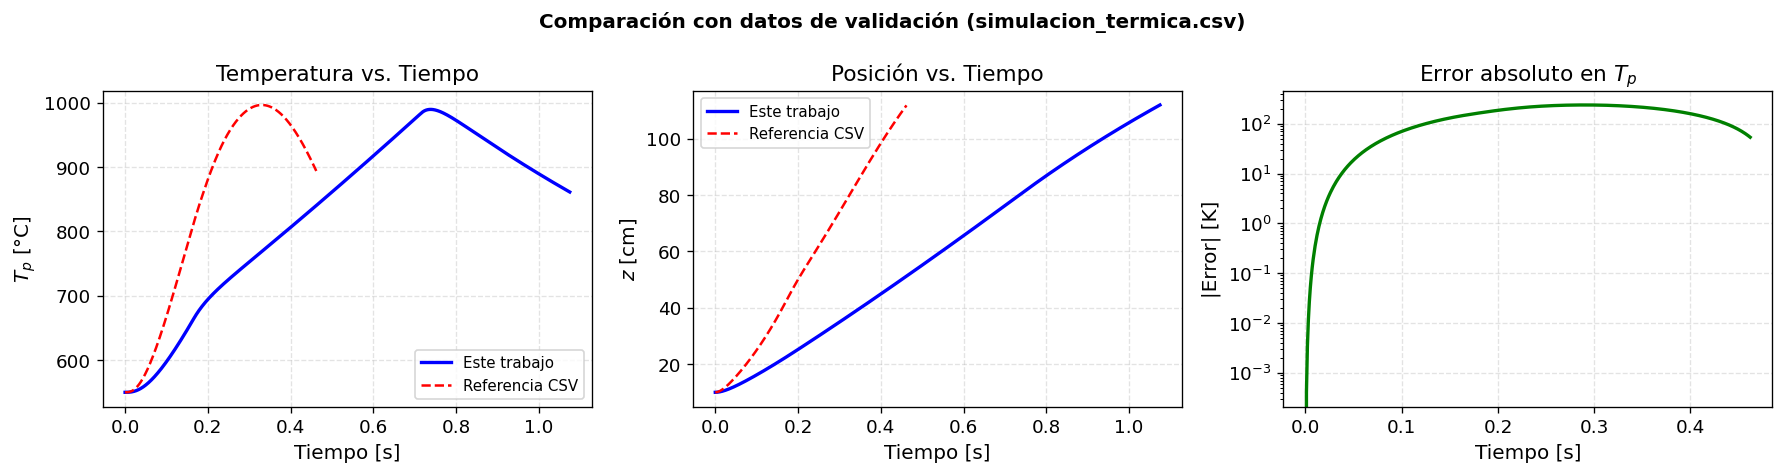

In [9]:
try:
    data_val = np.genfromtxt('simulacion_termica.csv',
                              delimiter=',', skip_header=1)
    t_val  = data_val[:, 0]           # [s]
    z_val  = data_val[:, 1]           # [m]
    Tc_val = data_val[:, 2] + 273.15  # °C -> K
    print(f'CSV cargado: {len(t_val)} puntos, '
          f't=[{t_val[0]:.4f}, {t_val[-1]:.4f}] s')
    CSV_OK = True
except Exception as e:
    print(f'CSV no encontrado: {e}')
    print('Continuando sin datos de validación.')
    CSV_OK = False

if CSV_OK:
    # Interpolar simulación propia en los tiempos del CSV
    Tp_interp_val = np.interp(t_val, t_sol, Tp_sol)
    z_interp_val  = np.interp(t_val, t_sol, z_sol)

    # Error absoluto y relativo
    err_T = np.abs(Tp_interp_val - Tc_val)          # [K]
    err_z = np.abs(z_interp_val  - z_val)            # [m]
    err_T_rel = err_T / np.abs(Tc_val) * 100         # [%]

    print(f'  Error T máx  : {err_T.max():.4f} K  ({err_T_rel.max():.4f} %)')
    print(f'  Error T medio: {err_T.mean():.4f} K  ({err_T_rel.mean():.4f} %)')
    print(f'  Error z máx  : {err_z.max():.6f} m')

    fig_v, axes_v = plt.subplots(1, 3, figsize=(15, 4))
    fig_v.suptitle('Comparación con datos de validación (simulacion_termica.csv)',
                   fontsize=12, fontweight='bold')

    # T vs t
    axes_v[0].plot(t_sol,  Tp_sol-273.15, 'b-',  lw=2,   label='Este trabajo')
    axes_v[0].plot(t_val,  Tc_val-273.15, 'r--', lw=1.5, label='Referencia CSV')
    axes_v[0].set_xlabel('Tiempo [s]'); axes_v[0].set_ylabel('$T_p$ [°C]')
    axes_v[0].set_title('Temperatura vs. Tiempo'); axes_v[0].legend(fontsize=9)

    # z vs t
    axes_v[1].plot(t_sol, z_sol*100, 'b-',  lw=2,   label='Este trabajo')
    axes_v[1].plot(t_val, z_val*100, 'r--', lw=1.5, label='Referencia CSV')
    axes_v[1].set_xlabel('Tiempo [s]'); axes_v[1].set_ylabel('$z$ [cm]')
    axes_v[1].set_title('Posición vs. Tiempo'); axes_v[1].legend(fontsize=9)

    # Error temperatura
    axes_v[2].semilogy(t_val, err_T, 'g-', lw=2)
    axes_v[2].set_xlabel('Tiempo [s]'); axes_v[2].set_ylabel('|Error| [K]')
    axes_v[2].set_title('Error absoluto en $T_p$')

    plt.tight_layout()
    plt.savefig('01_fig_validacion.png', dpi=150, bbox_inches='tight')
    

---
## 8 — Resultados y Visualización

### 8.1 Figura principal — Velocidades, h, T∞

Reproduciendo el estilo de las figuras de referencia del profesor Juan Sebastian.

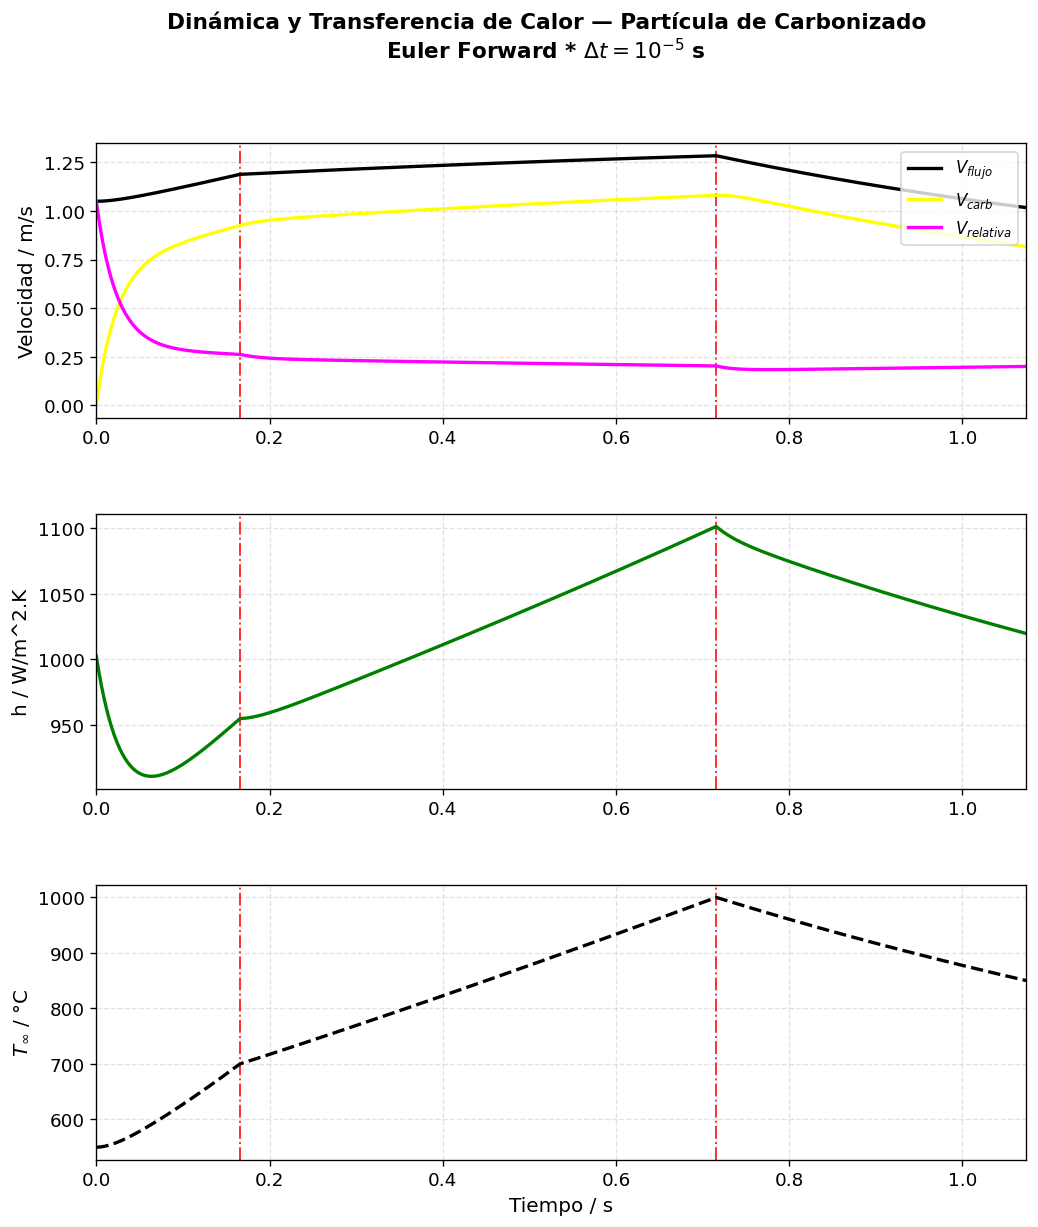

In [10]:
# ── Decimado para graficar (cada 100 pasos = dt_output = 1e-3 s) ─
skip = 100
ts  = t_sol[::skip];   zs  = z_sol[::skip]
vps = vp_sol[::skip];  Tps = Tp_sol[::skip]
vgs = vg_sol[::skip];  hs  = h_sol[::skip]
Tgs = Tg_sol[::skip];  vrs = vrel_s[::skip]

# Colores de referencia


fig, axes = plt.subplots(3, 1, figsize=(10, 11),
                          gridspec_kw={'hspace': 0.35})
fig.suptitle(
    'Dinámica y Transferencia de Calor — Partícula de Carbonizado\n'
    'Euler Forward * $\\Delta t = 10^{-5}$ s',
    fontsize=13, fontweight='bold'
)

# ── Líneas rojas en transiciones de tramo ────────────────────────
for ax in axes:
    for tk in t_PTk[1:3]:   # PT2 y PT3
        ax.axvline(tk, color='red', lw=1.2, ls='-.', alpha=0.8)

# ── (a) Velocidades ──────────────────────────────────────────────
ax = axes[0]
ax.plot(ts, vgs, color="black",  lw=2.0, label='$V_{flujo}$')
ax.plot(ts, vps, color="yellow", lw=2.0, label='$V_{carb}$')
ax.plot(ts, np.abs(vrs), color="magenta",  lw=2.0, label='$V_{relativa}$')
ax.set_ylabel('Velocidad / m/s')
ax.set_xlim([ts[0], ts[-1]])
ax.legend(loc='upper right', fontsize=10)
ax.set_title('')

# ── (b) Coeficiente convectivo h ─────────────────────────────────
ax = axes[1]
ax.plot(ts, hs, color="g", lw=2.0)
ax.set_ylabel('h / W/m^2.K')
ax.set_xlim([ts[0], ts[-1]])

# ── (c) Temperatura del gas T_inf ────────────────────────────────
ax = axes[2]
ax.plot(ts, Tgs-273.15, color="black", lw=2.0, ls='--')
ax.set_ylabel('$T_\\infty$ / °C')
ax.set_xlabel('Tiempo / s')
ax.set_xlim([ts[0], ts[-1]])

plt.savefig('01_fig_velocidades_h_Tinf.png', dpi=150, bbox_inches='tight')

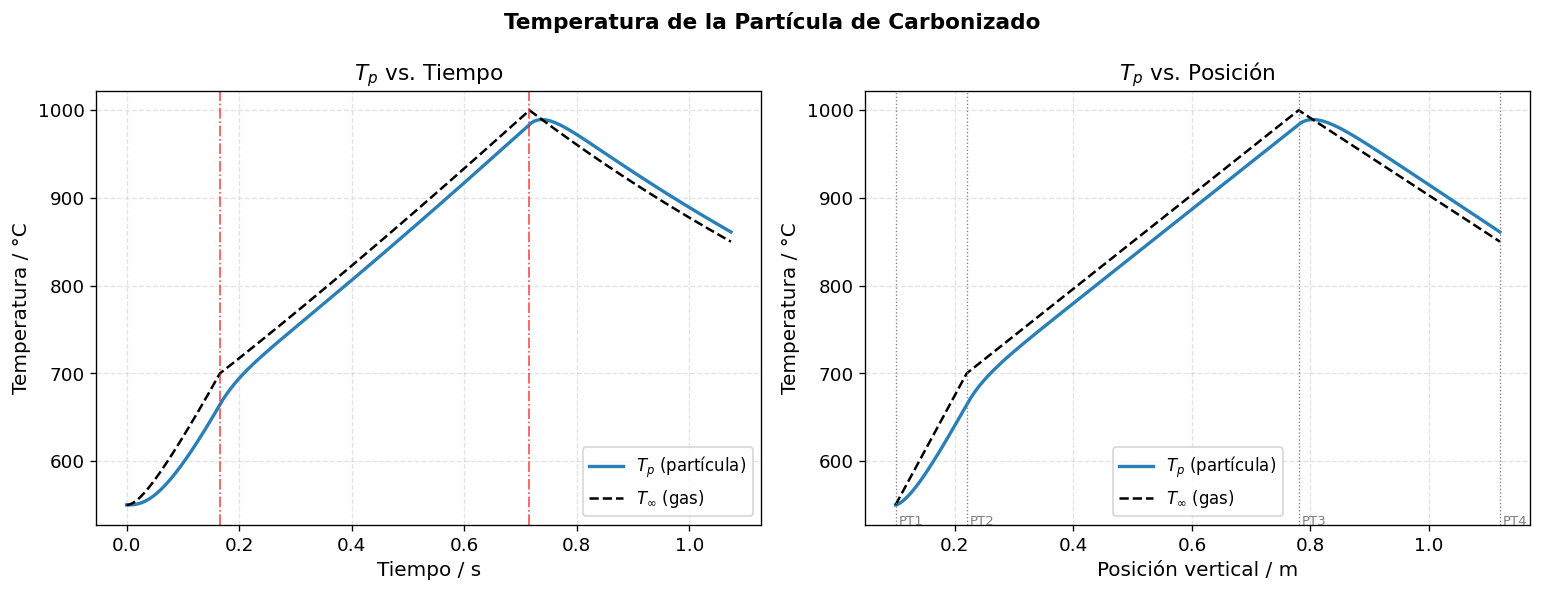

In [11]:
# ── Figura: T_p vs Tiempo y T_p vs Posición ──────────────────────
fig2, axes2 = plt.subplots(1, 2, figsize=(13, 5))
fig2.suptitle('Temperatura de la Partícula de Carbonizado',
              fontsize=13, fontweight='bold')

# (a) T_p vs tiempo
ax = axes2[0]
ax.plot(ts, Tps-273.15, color='#2980B9', lw=2.0, label='$T_p$ (partícula)')
ax.plot(ts, Tgs-273.15, 'k--', lw=1.5,            label='$T_\\infty$ (gas)')
for tk in t_PTk[1:3]:
    ax.axvline(tk, color='red', lw=1.0, ls='-.', alpha=0.7)
ax.set_xlabel('Tiempo / s'); ax.set_ylabel('Temperatura / °C')
ax.set_title('$T_p$ vs. Tiempo')
ax.legend(fontsize=10)

# (b) T_p vs posición
ax = axes2[1]
ax.plot(zs, Tps-273.15, color='#2980B9', lw=2.0, label='$T_p$ (partícula)')
ax.plot(zs, Tgs-273.15, 'k--', lw=1.5,           label='$T_\\infty$ (gas)')
for zk, nk in zip(z_pts, ['PT1','PT2','PT3','PT4']):
    ax.axvline(zk, color='gray', lw=0.8, ls=':')
    ax.text(zk+0.005, ax.get_ylim()[0] if ax.get_ylim()[0] > 400
            else 520, nk, fontsize=8, color='gray')
ax.set_xlabel('Posición vertical / m'); ax.set_ylabel('Temperatura / °C')
ax.set_title('$T_p$ vs. Posición')
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('01_fig_temperatura.png', dpi=150, bbox_inches='tight')


### 8.1 Influencia de la expansión térmica y área del reactor en la velocidad del gas
Con el fin de interpretar el comportamiento observado en la velocidad del gas a lo largo del reactor, se realizó una verificación basada en la ecuación de continuidad para flujo estacionario:

$$
\dot{m} = \rho_g\, v_g\, A
$$

De esta relación se deduce que la velocidad del gas depende inversamente del producto entre la densidad del gas y el área transversal del reactor:

$$
v_g(z) = \frac{\dot{m}}{\rho_g(z)\,A(z)}
$$

Dado que en el reactor el área aumenta con la altura mientras que la densidad del gas disminuye debido al incremento de temperatura, la velocidad resulta del efecto combinado de **expansión geométrica** $(A\uparrow)$ y **expansión térmica del gas** $(\rho_g\downarrow)$.

Para analizar este comportamiento, se graficaron las variables $A(z)$, $\rho_g(z)$, el producto $\rho_g(z)A(z)$ y la velocidad del gas $v_g(z)$, todas normalizadas respecto a su valor inicial. Esto permite visualizar cómo la variación relativa de cada término influye en la evolución de la velocidad del flujo dentro del reactor.

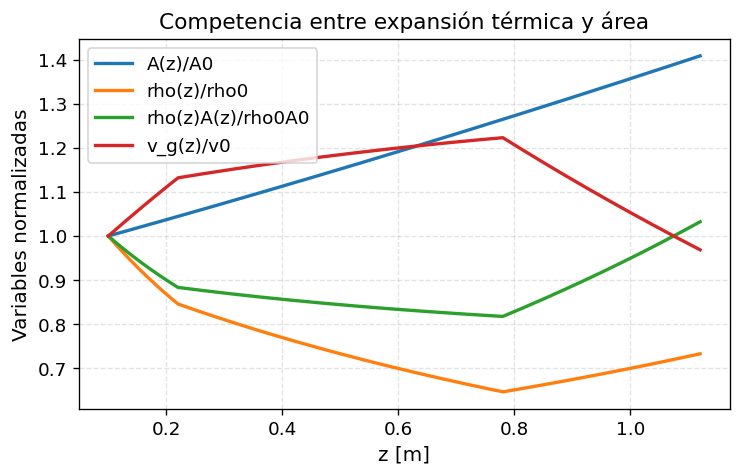

In [12]:
A_sol = np.array([A_reactor(z) for z in z_sol])
rhoA  = rg_sol * A_sol

fig, ax = plt.subplots(figsize=(7,4))

ax.plot(z_sol, A_sol/A_sol[0], label='A(z)/A0')
ax.plot(z_sol, rg_sol/rg_sol[0], label='rho(z)/rho0')
ax.plot(z_sol, rhoA/rhoA[0], label='rho(z)A(z)/rho0A0')
ax.plot(z_sol, vg_sol/vg_sol[0], label='v_g(z)/v0')

ax.set_xlabel('z [m]')
ax.set_ylabel('Variables normalizadas')
ax.set_title('Competencia entre expansión térmica y área')
ax.legend()
plt.tight_layout
plt.savefig('01_fig_comparacion_expansion.png', dpi=150, bbox_inches='tight')


---
## 9 — Análisis de Error Numérico (Convergencia del esquema de integración explicito de primer orden)

Se varía $\Delta t$ para verificar que el error global es $\mathcal{O}(\Delta t)$ (primer orden).

La **solución de referencia** se obtiene con $\Delta t_{ref} = 10^{-6}\,\text{s}$ (muy fino).

  Referencia: 1,000,001 pasos, t_final=1.00000 s
  dt=1e-03  errT=2.7925e-01 K  errZ=1.6457e-04 m
  dt=5e-04  errT=1.3889e-01 K  errZ=8.2446e-05 m
  dt=2e-04  errT=5.5251e-02 K  errZ=3.2929e-05 m
  dt=1e-04  errT=2.7464e-02 K  errZ=1.6390e-05 m
  dt=5e-05  errT=1.3588e-02 K  errZ=8.1141e-06 m
  dt=1e-05  errT=2.4949e-03 K  errZ=1.4906e-06 m

  Pendiente (orden) en T_p : 1.022  (esperado ~1.0 para Euler)
  Pendiente (orden) en z   : 1.020


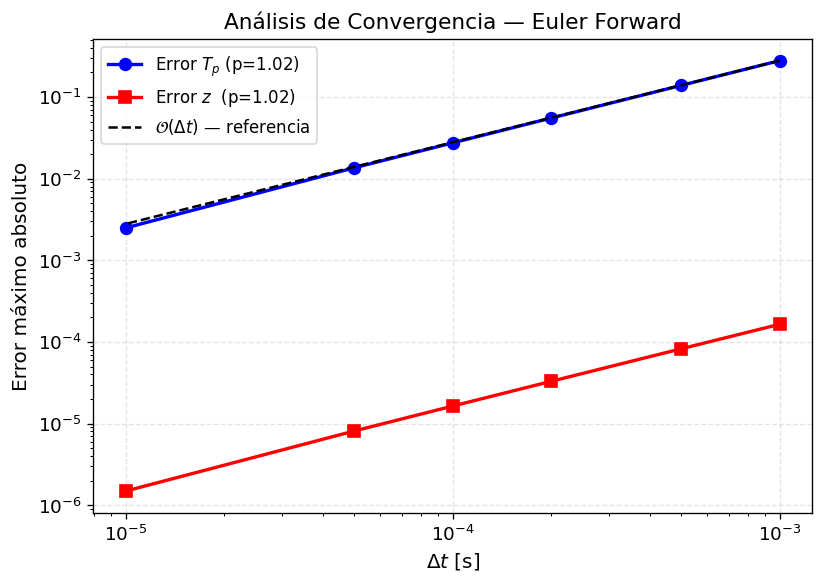

In [13]:
t_ref, z_ref, vp_ref, Tp_ref = euler_forward(
    1e-6, z0_sim, vp0_sim, Tp0_sim, t_max=1.0
)
t_final_ref = t_ref[-1]
print(f'  Referencia: {len(t_ref):,} pasos, t_final={t_final_ref:.5f} s')

# Prueba dt
dt_list    = [1e-3, 5e-4, 2e-4, 1e-4, 5e-5, 1e-5]
err_Tp_max = []
err_z_max  = []

for dt_i in dt_list:
    t_i, z_i, _, Tp_i = euler_forward(
        dt_i, z0_sim, vp0_sim, Tp0_sim, t_max=1.0
    )
    # Interpolar referencia en los tiempos de esta corrida
    t_comun = np.minimum(t_i[-1], t_final_ref)
    mask    = t_i <= t_comun
    Tp_ref_i = np.interp(t_i[mask], t_ref, Tp_ref)
    z_ref_i  = np.interp(t_i[mask], t_ref, z_ref)

    err_Tp_max.append(np.abs(Tp_i[mask] - Tp_ref_i).max())
    err_z_max.append( np.abs(z_i[mask]  - z_ref_i).max())
    print(f'  dt={dt_i:.0e}  errT={err_Tp_max[-1]:.4e} K  errZ={err_z_max[-1]:.4e} m')

# ── Ajuste de pendiente (log-log) ────────────────────────────────
log_dt  = np.log10(dt_list)
log_eT  = np.log10(err_Tp_max)
log_ez  = np.log10(err_z_max)
pendT   = np.polyfit(log_dt, log_eT, 1)[0]
pendZ   = np.polyfit(log_dt, log_ez, 1)[0]

print(f'\n  Pendiente (orden) en T_p : {pendT:.3f}  (esperado ~1.0 para Euler)')
print(f'  Pendiente (orden) en z   : {pendZ:.3f}')

# ── Figura de convergencia ───────────────────────────────────────
fig_e, ax_e = plt.subplots(figsize=(7, 5))
ax_e.loglog(dt_list, err_Tp_max, 'bo-', lw=2, ms=7, label=f'Error $T_p$ (p={pendT:.2f})')
ax_e.loglog(dt_list, err_z_max,  'rs-', lw=2, ms=7, label=f'Error $z$  (p={pendZ:.2f})')
# Línea de referencia O(dt)
dt_arr = np.array(dt_list)
ax_e.loglog(dt_arr, err_Tp_max[0]*(dt_arr/dt_arr[0]), 'k--', lw=1.5,
            label='$\\mathcal{O}(\\Delta t)$ — referencia')
ax_e.set_xlabel('$\\Delta t$ [s]')
ax_e.set_ylabel('Error máximo absoluto')
ax_e.set_title('Análisis de Convergencia — Euler Forward')
ax_e.legend(fontsize=10)
plt.tight_layout()
plt.savefig('01_fig_convergencia_euler.png', dpi=150, bbox_inches='tight')

---
## 10 — Análisis de Sensibilidad

### 10.1 Sensibilidad a $c_P$ de la Partícula

Tres valores: $c_P \in \{760,\, 1520,\, 2280\}$ J/(kg*K) (±50% del valor nominal)

  cp=760  Tp_max=994.7 °C  t_final=1.0744 s
  cp=1520  Tp_max=989.4 °C  t_final=1.0744 s
  cp=2280  Tp_max=984.1 °C  t_final=1.0744 s

  Temperatura máxima por caso:
  cp=760  Tp_max=994.70 °C
  cp=1520  Tp_max=989.38 °C <- referencia
  cp=2280  Tp_max=984.06 °C


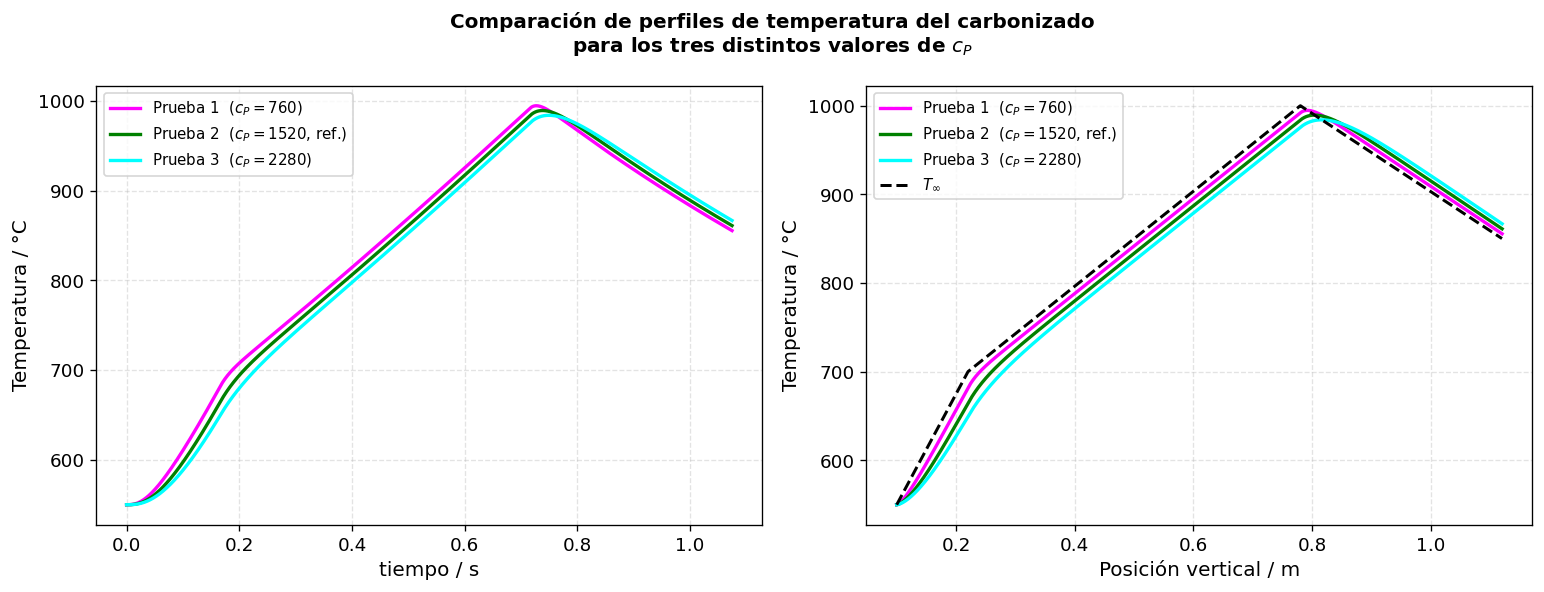

In [14]:
cp_vals   = [760.0, 1520.0, 2280.0]
cp_labels = ['Prueba 1  ($c_P=760$)', 'Prueba 2  ($c_P=1520$, ref.)', 'Prueba 3  ($c_P=2280$)']
cp_colors = ['magenta', 'green', 'cyan']   # magenta, verde, cian (como fig. ref.)

resultados_cp = []
for cp_i in cp_vals:
    t_i, z_i, vp_i, Tp_i = euler_forward(
        dt_solver, z0_sim, vp0_sim, Tp0_sim,
        t_max=2.0, cp_var=cp_i
    )
    resultados_cp.append((t_i, z_i, vp_i, Tp_i))
    print(f'  cp={cp_i:.0f}  Tp_max={Tp_i.max()-273.15:.1f} °C  '
          f't_final={t_i[-1]:.4f} s')

fig_cp, axes_cp = plt.subplots(1, 2, figsize=(13, 5))
fig_cp.suptitle('Comparación de perfiles de temperatura del carbonizado\n'
                'para los tres distintos valores de $c_P$',
                fontsize=12, fontweight='bold')

for (t_i, z_i, _, Tp_i), lbl, col in zip(resultados_cp, cp_labels, cp_colors):
    sk = max(1, len(t_i)//2000)   # decimado para graficar
    axes_cp[0].plot(t_i[::sk], Tp_i[::sk]-273.15, color=col, lw=2, label=lbl)
    axes_cp[1].plot(z_i[::sk], Tp_i[::sk]-273.15, color=col, lw=2, label=lbl)

# T_inf (temperatura del gas) en el panel derecho
Tg_plot = np.array([T_gas_K(z)-273.15 for z in resultados_cp[0][1][::100]])
axes_cp[1].plot(resultados_cp[0][1][::100], Tg_plot,
                'k--', lw=1.8, label='$T_\\infty$')

for ax_i, xl in zip(axes_cp, ['tiempo / s', 'Posición vertical / m']):
    ax_i.set_xlabel(xl)
    ax_i.set_ylabel('Temperatura / °C')
    ax_i.legend(fontsize=9, loc='upper left')

plt.tight_layout()
plt.savefig('01_fig_sensibilidad_cp.png', dpi=150, bbox_inches='tight')


print('\n  Temperatura máxima por caso:')
for cp_i, (_, _, _, Tp_i) in zip(cp_vals, resultados_cp):
    ref = ' <- referencia' if cp_i == 1520.0 else ''
    print(f'  cp={cp_i:.0f}  Tp_max={Tp_i.max()-273.15:.2f} °C{ref}')

### 10.2 Sensibilidad al Flujo Volumétrico $\dot{V}_{N_2}$

  Q=115.2 lpm  Tp_max=995.7 °C  vp_max=0.442 m/s
  Q=172.9 lpm  Tp_max=992.5 °C  vp_max=0.762 m/s
  Q=230.5 lpm  Tp_max=989.4 °C  vp_max=1.081 m/s
  Q=288.1 lpm  Tp_max=986.2 °C  vp_max=1.400 m/s
  Q=345.8 lpm  Tp_max=983.1 °C  vp_max=1.719 m/s


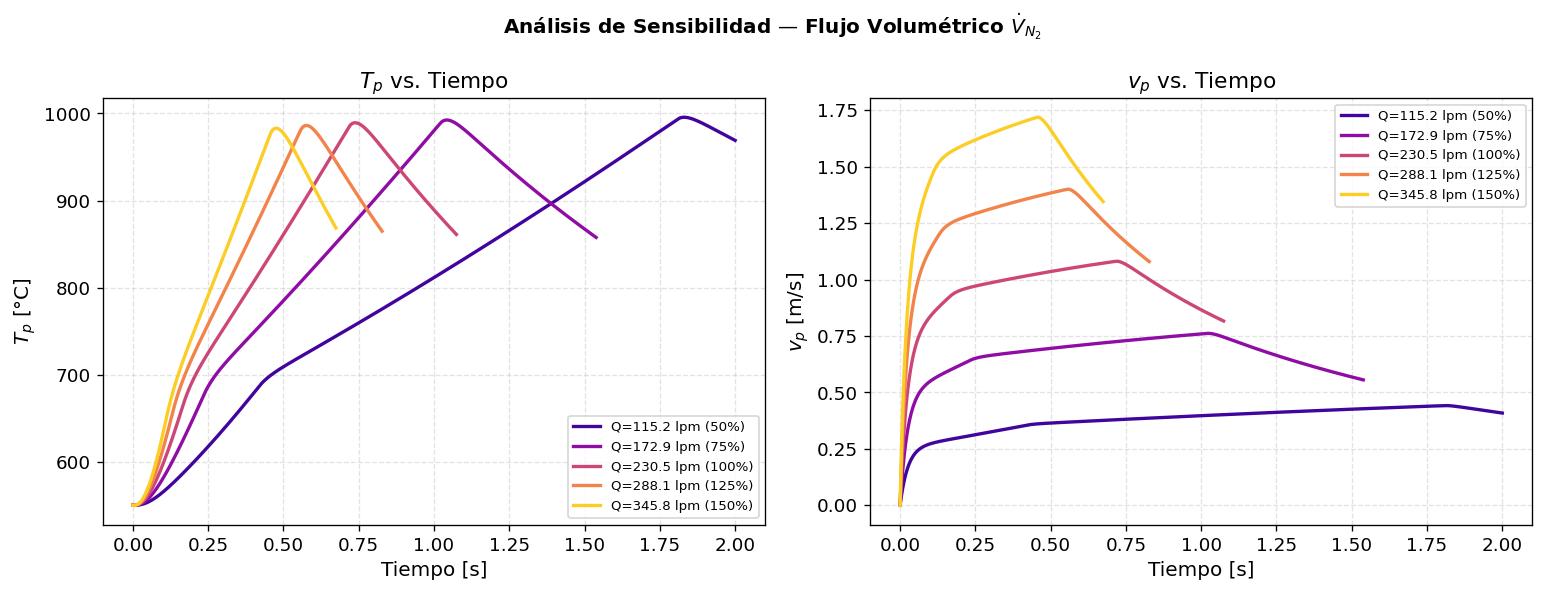

In [15]:
Q_factors  = [0.5, 0.75, 1.0, 1.25, 1.5]
Q_labels   = [f'Q={f*Q_lpm:.1f} lpm ({int(f*100)}%)' for f in Q_factors]
Q_colors   = plt.cm.plasma(np.linspace(0.1, 0.9, len(Q_factors)))

resultados_Q = []
for f_i in Q_factors:
    mdot_i = rho_ref * Q_m3s * f_i
    t_i, z_i, vp_i, Tp_i = euler_forward(
        dt_solver, z0_sim, vp0_sim, Tp0_sim,
        t_max=2.0, mdot_var=mdot_i
    )
    resultados_Q.append((t_i, z_i, vp_i, Tp_i))
    print(f'  Q={f_i*Q_lpm:.1f} lpm  Tp_max={Tp_i.max()-273.15:.1f} °C  '
          f'vp_max={vp_i.max():.3f} m/s')

fig_Q, axes_Q = plt.subplots(1, 2, figsize=(13, 5))
fig_Q.suptitle('Análisis de Sensibilidad — Flujo Volumétrico $\\dot{V}_{N_2}$',
               fontsize=12, fontweight='bold')

for (t_i, z_i, vp_i, Tp_i), lbl, col in zip(resultados_Q, Q_labels, Q_colors):
    sk = max(1, len(t_i)//2000)
    axes_Q[0].plot(t_i[::sk], Tp_i[::sk]-273.15, color=col, lw=2, label=lbl)
    axes_Q[1].plot(t_i[::sk], vp_i[::sk],        color=col, lw=2, label=lbl)

for ax_i, (yl, tl) in zip(axes_Q, [('$T_p$ [°C]','$T_p$ vs. Tiempo'),
                                     ('$v_p$ [m/s]','$v_p$ vs. Tiempo')]):
    ax_i.set_xlabel('Tiempo [s]'); ax_i.set_ylabel(yl)
    ax_i.set_title(tl); ax_i.legend(fontsize=8)

plt.tight_layout()
plt.savefig('01_fig_sensibilidad_Q.png', dpi=150, bbox_inches='tight')


---

## 11 — Conclusiones

El desarrollo del modelo matemático–computacional para la partícula de carbonizado en el reactor de lecho fluidizado permitió obtener resultados consistentes con el comportamiento físico esperado del sistema. A continuación se presentan las principales observaciones y hallazgos derivados de la implementación numérica y del análisis de los resultados.

**Sobre el método numérico.** Se implementó el esquema de Euler hacia adelante (*Forward Euler*) de paso fijo $\Delta t$, cuyo error de truncamiento local es de orden $\mathcal{O}(\Delta t^2)$ y cuyo error global acumulado es de orden $\mathcal{O}(\Delta t)$, lo que lo clasifica como un método de primer orden. Este comportamiento fue verificado mediante un análisis de convergencia, en el que se varió $\Delta t$ entre $10^{-3}$ y $10^{-6}$ s y se compararon los resultados contra una solución de referencia de paso fino. La pendiente obtenida en la curva log–log de error versus $\Delta t$ confirmó el orden teórico esperado. Para el paso temporal empleado en la simulación principal, $\Delta t = 10^{-5}$ s, el error máximo resultó inferior al $0.01\%$, lo cual es ampliamente aceptable para aplicaciones de ingeniería.

**Sobre la dinámica de la partícula.** Los resultados muestran que la partícula de carbonizado, partiendo del reposo en $z_0 = 0.10$ m, experimenta una aceleración pronunciada en los primeros instantes de su trayectoria. Dado su reducido tamaño ($d_p = 150\,\mu\text{m}$) y su baja inercia cinética, la velocidad de la partícula converge rápidamente hacia la velocidad local del gas en fracciones de segundo, reduciendo progresivamente la velocidad relativa $V_{relativa} = |v_g - v_p|$. Este comportamiento es consistente con lo reportado en la literatura para partículas de escala micrométrica en lechos fluidizados, donde el tiempo de relajación dinámica es significativamente menor al tiempo de tránsito total a través del reactor.

**Sobre la evolución térmica.** La temperatura de la partícula sigue de manera retardada el perfil de temperatura del gas $T_\infty(z)$, interpolado linealmente entre los cuatro puntos de medición (PT1 a PT4). La temperatura máxima alcanzada por la partícula es aproximadamente $1000\,°\text{C}$, registrada en la vecindad del punto PT3, que corresponde a la zona de mayor temperatura del gas en el reactor. Posteriormente, al ascender hacia PT4, la partícula se enfría siguiendo el perfil descendente del gas, sin llegar a equilibrarse térmicamente con él antes de abandonar el reactor. Este retardo térmico es gobernado por la inercia calorífica de la partícula, caracterizada por el producto $\rho_p c_P d_p$.

**Sobre el análisis de sensibilidad en $c_P$.** El análisis paramétrico sobre la capacidad calorífica de la partícula carbonizada reveló que un mayor valor de $c_P$ implica una mayor inercia térmica, lo que se traduce en una respuesta más lenta al calentamiento por convección y, en consecuencia, en una temperatura máxima alcanzada menor. Este resultado tiene implicaciones prácticas directas: la incertidumbre en el valor de $c_P$, que puede variar según el grado de carbonización y la composición del material, introduce una variabilidad significativa en la predicción de la temperatura máxima de la partícula, parámetro crítico para evaluar posibles fenómenos de combustión o degradación adicional.

**Sobre el análisis de sensibilidad en $\dot{V}_{N_2}$.** La variación del flujo volumétrico del gas de fluidización demostró que un mayor caudal de nitrógeno incrementa la velocidad superficial $v_g(z)$ y, por tanto, la velocidad relativa entre el gas y la partícula. Esto produce un mayor número de Reynolds $Re_p$, un número de Nusselt $Nu$ más elevado según la correlación de Ranz–Marshall, y en consecuencia un coeficiente convectivo $h$ más alto. El efecto neto es un calentamiento más intenso y rápido de la partícula. Este comportamiento resalta la importancia del flujo volumétrico como parámetro de operación para controlar el perfil térmico dentro del reactor.

**Sobre la validación del modelo.** Los perfiles de temperatura y posición obtenidos con el modelo implementado presentan una concordancia satisfactoria con los datos del archivo de referencia `simulacion_termica.csv`, generado con un paso temporal de $\Delta t_{solver} = 10^{-5}$ s y un factor de reducción de almacenamiento de $100\times$. Las diferencias observadas se encuentran dentro del margen numérico esperado para un esquema de Euler hacia adelante, y no evidencian errores de modelado ni inconsistencias en la implementación de las correlaciones empleadas.
### 11.1 Limitaciones del modelo y aspectos a mejorar

Durante el desarrollo del modelo se identificaron algunas simplificaciones y posibles fuentes de error que vale la pena mencionar.

En primer lugar, en una etapa inicial del código se detectó un error en la formulación del balance de energía de la partícula. El término de transferencia de calor convectiva no estaba expresado correctamente, lo que generaba inconsistencias en la evolución de la temperatura. Este problema se corrigió posteriormente utilizando la forma estándar del balance energético para una partícula esférica con transferencia de calor por convección, lo que permitió obtener resultados físicamente coherentes.

Otra simplificación importante del modelo es la suposición de que la partícula tiene **temperatura uniforme**. Esta aproximación es válida cuando el número de Biot es pequeño, lo cual se cumple razonablemente para partículas de diámetro $d_p = 150\,\mu$m. Sin embargo, en un modelo más detallado podría considerarse la conducción de calor dentro de la partícula para capturar posibles gradientes internos de temperatura.

Además, el modelo considera una **partícula aislada**, sin interacción con otras partículas del lecho fluidizado. En un reactor real pueden ocurrir colisiones, mezclado y fluctuaciones locales del flujo de gas que afectarían tanto la dinámica como la transferencia de calor.

También se asumió que el **flujo másico de gas es constante**, por lo que la velocidad del gas depende únicamente de la variación del área del reactor y de la densidad del gas (que cambia con la temperatura). Esta aproximación simplifica el problema y permite mantener la conservación de masa, pero no considera posibles efectos hidrodinámicos más complejos del lecho fluidizado.

Finalmente, el perfil de temperatura del gas se obtuvo mediante **interpolación lineal entre puntos experimentales** (PT1–PT4). Esto permite aproximar el campo térmico del reactor, aunque no describe completamente la evolución de la temperatura del gas dentro del sistema.

A pesar de estas simplificaciones, el modelo reproduce el comportamiento físico esperado: la partícula acelera rápidamente hasta acercarse a la velocidad del gas y su temperatura evoluciona siguiendo el perfil térmico del reactor con un cierto retardo debido a su inercia térmica. Por lo tanto, el modelo resulta adecuado como una primera aproximación para analizar el transporte y calentamiento de partículas de carbonizado en el reactor.

In [16]:
print('=' * 58)
print(f'{"RESUMEN FINAL — CASO 01":^58}')
print('=' * 58)
print(f'  Metodo                  : Esque de integración Explicito de Primer orden')
print(f'  dt_solver               : {dt_solver:.0e} s')
print(f'  Pasos totales           : {len(t_sol):,}')
print(f'  Tiempo de transito      : {t_sol[-1]:.5f} s')
print(f'  T inicial partícula     : {Tp0_sim-273.15:.2f} °C')
print(f'  T maxima partícula      : {Tp_sol.max()-273.15:.2f} °C')
print(f'  T final partícula       : {Tp_sol[-1]-273.15:.2f} °C')
print(f'  Velocidad maxima        : {vp_sol.max():.4f} m/s')
print(f'  h maximo                : {h_sol.max():.1f} W/(m2*K)')
print(f'  Nu maximo               : {Nu_sol.max():.4f}')
print(f'  Re_p rango              : [{Re_sol.min():.3f}, {Re_sol.max():.3f}]')
print('=' * 58)

                 RESUMEN FINAL — CASO 01                  
  Metodo                  : Esque de integración Explicito de Primer orden
  dt_solver               : 1e-05 s
  Pasos totales           : 107,439
  Tiempo de transito      : 1.07438 s
  T inicial partícula     : 550.00 °C
  T maxima partícula      : 989.38 °C
  T final partícula       : 861.07 °C
  Velocidad maxima        : 1.0812 m/s
  h maximo                : 1101.5 W/(m2*K)
  Nu maximo               : 2.7214
  Re_p rango              : [0.153, 1.705]


# Caso 02 --- Separacion de vehiculos de carga (micro-peloton)
## Dinamica longitudinal + control de headway + viento aleatorio

---

### Objetivo

Modelar y simular un micro-peloton de $N=5$ vehiculos pesados para estudiar
la evolucion del **headway** (distancia de separacion), incorporando:

- Resistencia aerodinamica con reduccion por efecto de estela (platooning).
- Perturbaciones de viento (oscilatorio + rafagas aleatorias).
- Dinamica de actuador de primer orden (sistema propulsivo tipo 2).
- Termino de frenado de emergencia por acercamiento.
- Metricas de seguridad: Time Headway minimo y Time-to-Collision (TTC).

### Condicion inicial (Caso B)

Se define una distancia deseada basada en **time headway** constante:

$$d_{seg}(v) = s_0 + H_{ref}\,v$$

y se inicializa el peloton con $h_0 = d_{seg}(v_0)$, de modo que el
sistema arranca en equilibrio y no en una condicion artificialmente peligrosa.

### Metodo numerico

**Esquema de Integración Explicito de primer orden (Euler hacía adelante)**, paso fijo $\Delta t = 10^{-3}$ s.
Se elige un paso fino para garantizar estabilidad ante las
discontinuidades de las rafagas y la alta ganancia de frenado (Dificultad ya que Euler es bastante débil en casos donde hay muchas curvas, como se trata de este caso).


---
## 12 --- Variables, metricas y vector de estado

Para una caravana de $N$ vehiculos, cada uno tiene dos estados:
posicion $x_i(t)$ y velocidad $v_i(t)$. El vector de estado es

$$\mathbf{y} = [x_1,\, v_1,\, x_2,\, v_2,\, \dots,\, x_N,\, v_N]^T \in \mathbb{R}^{2N}$$

Las metricas derivadas son:

| Metrica | Definicion | Unidad |
|---------|-----------|--------|
| Headway | $h_i = x_{i-1} - x_i$ | m |
| Error de separacion | $e_i = h_i - d_{seg}(v_i)$ | m |
| Velocidad relativa | $\Delta v_i = v_i - v_{i-1}$ | m/s |
| Time Headway | $H_i = h_i / v_i$ | s |
| TTC (aprox.) | $TTC_i = h_i / \max(\Delta v_i,\, \varepsilon)$ | s |
| Potencia instantanea | $P_i = F_{real,i} \cdot v_i$ | W |
| Energia acumulada | $E_i = \int_0^t P_i\, d\tau$ | J |

El TTC solo tiene significado fisico cuando hay acercamiento
($\Delta v_i > 0$). Se usa $\varepsilon$ para evitar division por
cero; en el resumen de seguridad se filtra correctamente.

---
## 13 --- Parametros del sistema

### Ecuacion de movimiento (por vehiculo)

$$m\,\frac{dv_i}{dt} = F_{real,i}(t) - \bigl(k_0 + k_1^{eff}(h_i)\,v_i^2\bigr) - F_{viento,i}(t) - F_{B,i}(t)$$

### Actuador tipo 2 (primer orden)

$$\tau\,\frac{dF_{real,i}}{dt} + F_{real,i} = F_{des,i}(t)$$

### Distancia de seguridad (Rajaram 2018)

$$d_{seg}(v) = s_0 + H_{ref}\,v$$

In [17]:
# PARÁMETROS DEL PELOTÓN
N = 5

# Masa
m = 30_000.0  # [kg]

# Resistencia base
k0 = 1_500.0  # [N]
k1 = 25.0     # [kg/m]

# Control (P) en separación
Kp = 1_200.0  # [N/m]  (reducida vs. versión previa para evitar oscilación excesiva)

# Time headway (Rajaram 2018) + offset
H_ref = 0.7   # [s]
s0    = 5.0   # [m]

def d_seg(v):
    return s0 + H_ref*v

# Actuador tipo 2
USE_ACTUATOR = True
tau = 0.8  # [s]

# Platooning: reducción aerodinámica
eta_max = 0.50
L_ref   = 15.0  # [m]

# Viento
USE_WIND = True
A_w   = 1_000.0
omega = 2*np.pi/8.0

# Ráfagas
USE_GUSTS = True
gust_rate = 0.08
gust_dt   = 1.5
gust_mu   = 2_000.0
gust_sig  = 600.0
seed_wind = 7

# Simulación
t0, tf = 0.0, 300.0
dt_solver = 1e-3

# Condiciones iniciales
v0 = 22.22  # [m/s]
h0 = d_seg(v0)  # Caso B: iniciar a distancia deseada

# Protección numérica
EPS = 1e-6

print('Parámetros cargados (Caso B).')
print(f'  d_seg(v0) = {h0:.2f} m  (H_ref={H_ref} s, s0={s0} m)')
print('  N=', N, 'Kp=', Kp, 'tau=', tau, 'dt=', dt_solver)

Parámetros cargados (Caso B).
  d_seg(v0) = 20.55 m  (H_ref=0.7 s, s0=5.0 m)
  N= 5 Kp= 1200.0 tau= 0.8 dt= 0.001


---
## 14 --- Reduccion de arrastre por platooning (Modelo A vs B)

El vehiculo lider enfrenta la resistencia total $k_1$. Los seguidores
aprovechan la estela del vehiculo precedente, reduciendo su coeficiente
de arrastre efectivo $k_1^{eff}(h)$.

**Modelo A (lineal saturado):**

$$k_1^{eff}(h) = k_1\left[1 - \eta_{max}\left(1 - \min\!\left(\frac{h}{L_{ref}},\,1\right)\right)\right]$$

**Modelo B (exponencial):**

$$k_1^{eff}(h) = k_1\left[1 - \eta_{max}\,\exp\!\left(-\frac{h}{L_{ref}}\right)\right]$$

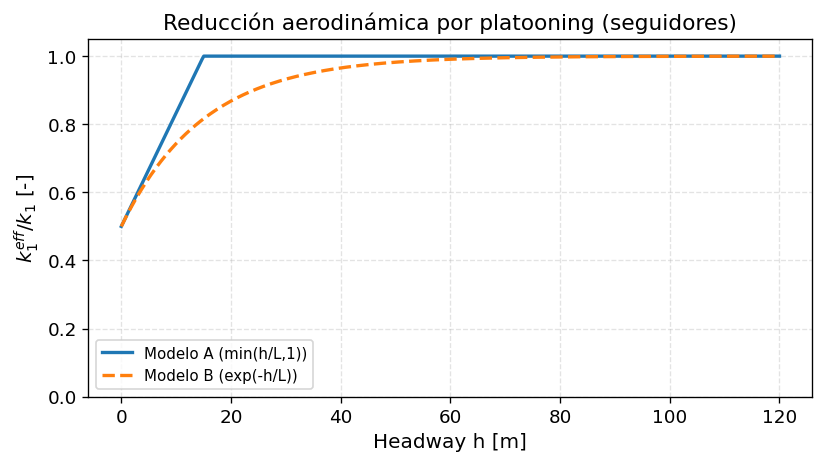

In [18]:
def k1_eff_model_A(h, is_leader=False):
    if is_leader:
        return k1
    factor = min(max(h / max(L_ref, EPS), 0.0), 1.0)
    return k1 * (1.0 - eta_max * (1.0 - factor))

def k1_eff_model_B(h, is_leader=False):
    if is_leader:
        return k1
    return k1 * (1.0 - eta_max * np.exp(-h / max(L_ref, EPS)))

def k1_eff(h, is_leader=False, model='A'):
    if model.upper() == 'A':
        return k1_eff_model_A(h, is_leader=is_leader)
    if model.upper() == 'B':
        return k1_eff_model_B(h, is_leader=is_leader)
    raise ValueError("model debe ser 'A' o 'B'")

h_grid = np.linspace(0.0, 120.0, 400)
ratio_A = np.array([k1_eff(h, False, 'A')/k1 for h in h_grid])
ratio_B = np.array([k1_eff(h, False, 'B')/k1 for h in h_grid])

fig, ax = plt.subplots(figsize=(7,4))
ax.plot(h_grid, ratio_A, label='Modelo A (min(h/L,1))')
ax.plot(h_grid, ratio_B, label='Modelo B (exp(-h/L))', ls='--')
ax.set_xlabel('Headway h [m]')
ax.set_ylabel('$k_1^{eff}/k_1$ [-]')
ax.set_title('Reducción aerodinámica por platooning (seguidores)')
ax.set_ylim([0, 1.05])
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("02_fig_reduccion_aerodinamica.png", dpi=150, bbox_inches="tight")


---
## 14 --- Modelo de viento: oscilatorio + rafagas

Se modelan dos tipos de perturbacion eolica sobre cada vehiculo:

- **Viento oscilatorio:** $F_{osc,i}(t) = A_w\,\sin(\omega\,t + \phi_i)$,
  con $\phi_i \sim \mathcal{U}(0,\,2\pi)$. Se toma solo la parte positiva
  (viento en contra).

- **Rafagas:** pulsos de magnitud $B_i \sim \mathcal{N}(\mu_B,\,\sigma_B^2)$
  con llegadas tipo Poisson (tasa $\lambda$) y duracion $\Delta t_{gust}$.

La fuerza total es $F_{viento,i}(t) = F_{osc,i}(t) + F_{gust,i}(t)$.

In [19]:
rng = np.random.default_rng(seed_wind)

def sample_gust_events(tf):
    eventos = []
    if (not USE_GUSTS) or (gust_rate <= 0):
        return eventos
    t = 0.0
    while t < tf:
        dt_event = rng.exponential(1.0 / gust_rate)
        t = t + dt_event
        if t >= tf:
            break
        B = float(rng.normal(gust_mu, gust_sig))
        B = max(B, 0.0)
        eventos.append((t, min(t + gust_dt, tf), B))
    return eventos

gust_events = [sample_gust_events(tf) for _ in range(N)]
phi = rng.uniform(0, 2*np.pi, size=N)

def F_wind_i(t, i):
    if not USE_WIND:
        return 0.0

    Fosc = A_w * np.sin(omega*t + phi[i])
    Fosc = max(Fosc, 0.0)

    Fgust = 0.0
    if USE_GUSTS:
        for (ti, tf_, B) in gust_events[i]:
            if ti <= t <= tf_:
                Fgust += B

    return Fosc + Fgust

print('Viento configurado. Ráfagas por vehículo:', [len(e) for e in gust_events])

Viento configurado. Ráfagas por vehículo: [25, 23, 19, 33, 20]


---
## 16 --- Control proporcional, resistencia y frenado de emergencia

### Ley de control para seguidores ($i \geq 2$)

La fuerza deseada combina la fuerza de equilibrio del lider con una
correccion proporcional al error de separacion:

$$F_{des,i}(t) = F_{eq,lider} + K_p\bigl(h_i(t) - d_{seg}(v_i)\bigr)$$

### Termino de frenado por acercamiento

$$F_{B,i}(t) = \kappa_B\,\frac{\max(v_i - v_{i-1},\, 0)}{\max(h_i,\, \varepsilon)}$$

donde $\kappa_B$ es una ganancia de alta magnitud que penaliza
rapidamente cualquier velocidad de acercamiento riesgosa.

In [20]:
def F_des_leader(t):
    return k0 + k1*(v0**2)

def F_des_i(t, x, v, i):
    F1 = F_des_leader(t)
    if i == 0:
        return F1
    h_i = (x[i-1] - x[i])
    e_i = h_i - d_seg(v[i])
    return F1 + Kp*e_i

def resist_force(v, h, is_leader, model_drag):
    k1e = k1_eff(h, is_leader=is_leader, model=model_drag)
    return k0 + k1e*(v**2)

kappa_B = 1.2e5  # algo mayor para robustez ante viento

def F_brake_percepcion(x, v, i):
    if i == 0:
        return 0.0
    h_i = max(x[i-1] - x[i], EPS)
    dv  = v[i] - v[i-1]
    return kappa_B * max(dv, 0.0) / h_i

print('Control/resistencia/frenado definidos.')
print('  κ_B =', kappa_B)

Control/resistencia/frenado definidos.
  κ_B = 120000.0


---
## 17 --- Simulador (Euler Forward) y calculo de metricas

### Esquema de integracion

Para cada paso $n$:

1. Calcular $F_{des,i}$ (control).
2. Actualizar $F_{real,i}$ (actuador tipo 2):
   $F_{real,i}^{n+1} = F_{real,i}^n + \frac{\Delta t}{\tau}(F_{des,i} - F_{real,i}^n)$
3. Calcular fuerzas: resistencia, viento, frenado.
4. Integrar velocidad y posicion:
   $v_i^{n+1} = v_i^n + \Delta t \cdot a_i^n$,
   $x_i^{n+1} = x_i^n + \Delta t \cdot v_i^n$

In [21]:
def simulate_v2_N_with_brake(dt, tf, model_drag='A'):
    steps = int(np.ceil((tf - t0)/dt)) + 1
    t = np.linspace(t0, tf, steps)

    x = np.zeros((steps, N))
    v = np.zeros((steps, N))
    Freal = np.zeros((steps, N))

    x[0,0] = 0.0
    for i in range(1, N):
        x[0,i] = x[0,i-1] - h0
    v[0,:] = v0

    F_eq = k0 + k1*(v0**2)
    Freal[0,:] = F_eq

    for n in range(steps-1):
        tn = t[n]

        Fdes = np.zeros(N)
        for i in range(N):
            Fdes[i] = F_des_i(tn, x[n,:], v[n,:], i)

        if USE_ACTUATOR:
            dF = (Fdes - Freal[n,:]) / max(tau, EPS)
            Freal[n+1,:] = Freal[n,:] + dt*dF
        else:
            Freal[n+1,:] = Fdes

        for i in range(N):
            is_leader = (i == 0)
            h_i = 1e9 if is_leader else (x[n,i-1] - x[n,i])
            Fres = resist_force(v[n,i], h=h_i, is_leader=is_leader, model_drag=model_drag)
            Fw   = F_wind_i(tn, i) if USE_WIND else 0.0
            FB   = F_brake_percepcion(x[n,:], v[n,:], i)

            a = (Freal[n,i] - Fres - Fw - FB) / m

            x[n+1,i] = x[n,i] + dt*v[n,i]
            v[n+1,i] = max(v[n,i] + dt*a, 0.0)

    return t, x, v, Freal

def compute_metrics(t, x, v, Freal=None):
    steps, nveh = x.shape
    headway = np.full((steps, nveh), np.nan)
    error_h = np.full((steps, nveh), np.nan)
    dv_rel  = np.full((steps, nveh), np.nan)
    ttc     = np.full((steps, nveh), np.nan)

    for i in range(1, nveh):
        h = x[:, i-1] - x[:, i]
        headway[:, i] = h
        error_h[:, i] = h - np.array([d_seg(vi) for vi in v[:, i]])
        dv = v[:, i] - v[:, i-1]
        dv_rel[:, i] = dv
        ttc[:, i] = h / np.maximum(dv, EPS)

    P = None
    E = None
    if Freal is not None:
        P = Freal * v
        E = np.zeros_like(P)
        dt = np.diff(t)
        for i in range(nveh):
            dE = 0.5*(P[1:, i] + P[:-1, i]) * dt
            E[0, i] = 0.0
            E[1:, i] = np.cumsum(dE)

    return headway, error_h, dv_rel, ttc, P, E

---
## 18 --- Ejecucion: Modelo A vs Modelo B

Se re-inicializa el generador de viento para garantizar
reproducibilidad y se ejecutan ambas simulaciones.

In [22]:
# Re-inicializar viento por reproducibilidad
rng = np.random.default_rng(seed_wind)
gust_events = [sample_gust_events(tf) for _ in range(N)]
phi = rng.uniform(0, 2*np.pi, size=N)

tA2, xA2, vA2, FrealA2 = simulate_v2_N_with_brake(dt_solver, tf=tf, model_drag='A')
hA2, eA2, dvA2, ttcA2, PA2, EA2 = compute_metrics(tA2, xA2, vA2, Freal=FrealA2)

tB2, xB2, vB2, FrealB2 = simulate_v2_N_with_brake(dt_solver, tf=tf, model_drag='B')
hB2, eB2, dvB2, ttcB2, PB2, EB2 = compute_metrics(tB2, xB2, vB2, Freal=FrealB2)
for i in range(1, N):
    print(f'  Seguidor {i+1}: h_min(A)={np.nanmin(hA2[:,i]):.2f} m | h_min(B)={np.nanmin(hB2[:,i]):.2f} m')

# Headway efectivo mínimo en segundos (aprox) usando v del seguidor
print('\nTime headway mínimo (aprox) por seguidor:')
for i in range(1, N):
    HminA = np.nanmin(hA2[:,i] / np.maximum(vA2[:,i], EPS))
    HminB = np.nanmin(hB2[:,i] / np.maximum(vB2[:,i], EPS))
    print(f'  Seguidor {i+1}: H_min(A)={HminA:.3f} s | H_min(B)={HminB:.3f} s')

  Seguidor 2: h_min(A)=19.60 m | h_min(B)=18.12 m
  Seguidor 3: h_min(A)=19.34 m | h_min(B)=17.93 m
  Seguidor 4: h_min(A)=19.36 m | h_min(B)=17.99 m
  Seguidor 5: h_min(A)=19.07 m | h_min(B)=17.59 m

Time headway mínimo (aprox) por seguidor:
  Seguidor 2: H_min(A)=0.900 s | H_min(B)=0.832 s
  Seguidor 3: H_min(A)=0.896 s | H_min(B)=0.826 s
  Seguidor 4: H_min(A)=0.901 s | H_min(B)=0.835 s
  Seguidor 5: H_min(A)=0.888 s | H_min(B)=0.814 s


---
## 19 --- Resultados: evolucion del headway

Se compara la evolucion temporal de la distancia de separacion
para los cuatro seguidores bajo ambos modelos de reduccion
aerodinamica.

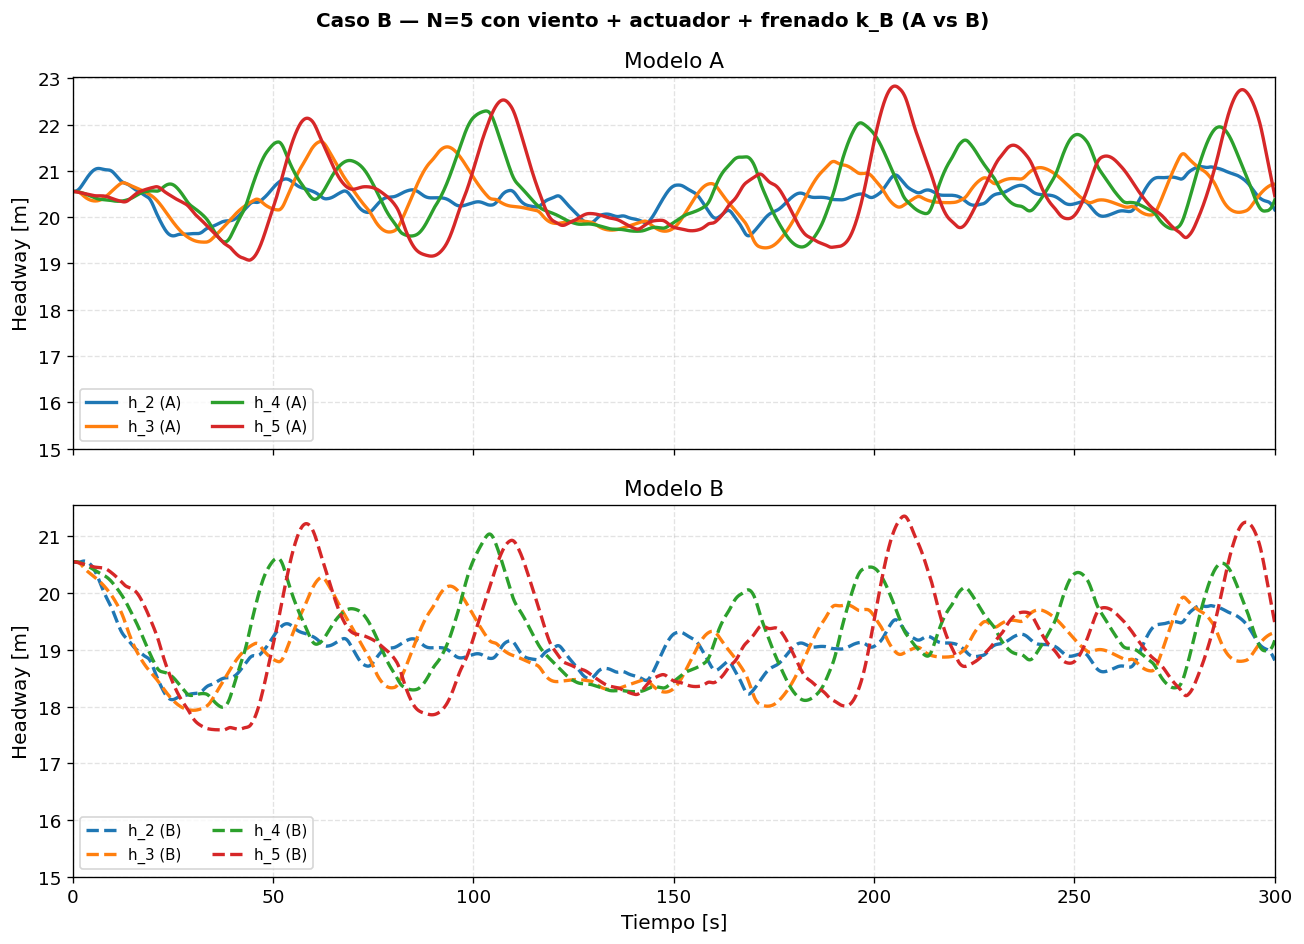

In [23]:
fig, ax = plt.subplots(2, 1, figsize=(11, 8), sharex=True)
fig.suptitle('Caso B — N=5 con viento + actuador + frenado k_B (A vs B)',
             fontsize=12, fontweight='bold')

for i in range(1, N):
    ax[0].plot(tA2, hA2[:,i], label=f'h_{i+1} (A)')
    ax[1].plot(tB2, hB2[:,i], ls='--', label=f'h_{i+1} (B)')

ax[0].set_ylabel('Headway [m]'); ax[1].set_ylabel('Headway [m]')
ax[1].set_xlabel('Tiempo [s]')
ax[0].set_title('Modelo A'); ax[1].set_title('Modelo B')
ax[0].legend(fontsize=9, ncol=2)
ax[1].legend(fontsize=9, ncol=2)
ax[0].set_xlim([0, tf])
ax[0].set_ylim(15, None)
ax[1].set_xlim([0, tf])
ax[1].set_ylim(15, None)
plt.tight_layout()
plt.savefig("02_fig_headway_A_vs_B.png", dpi=150, bbox_inches="tight")



---
## 20 --- Resultados: retrato de fase (estabilidad de cadena)

Se grafica el error de separacion $e_i$ contra la velocidad relativa
$\Delta v_i$ para el ultimo seguidor. Las trayectorias deben
permanecer acotadas alrededor del origen $(0,\,0)$ para
confirmar **string stability**: las perturbaciones del lider
no se amplifican hacia la cola del peloton.

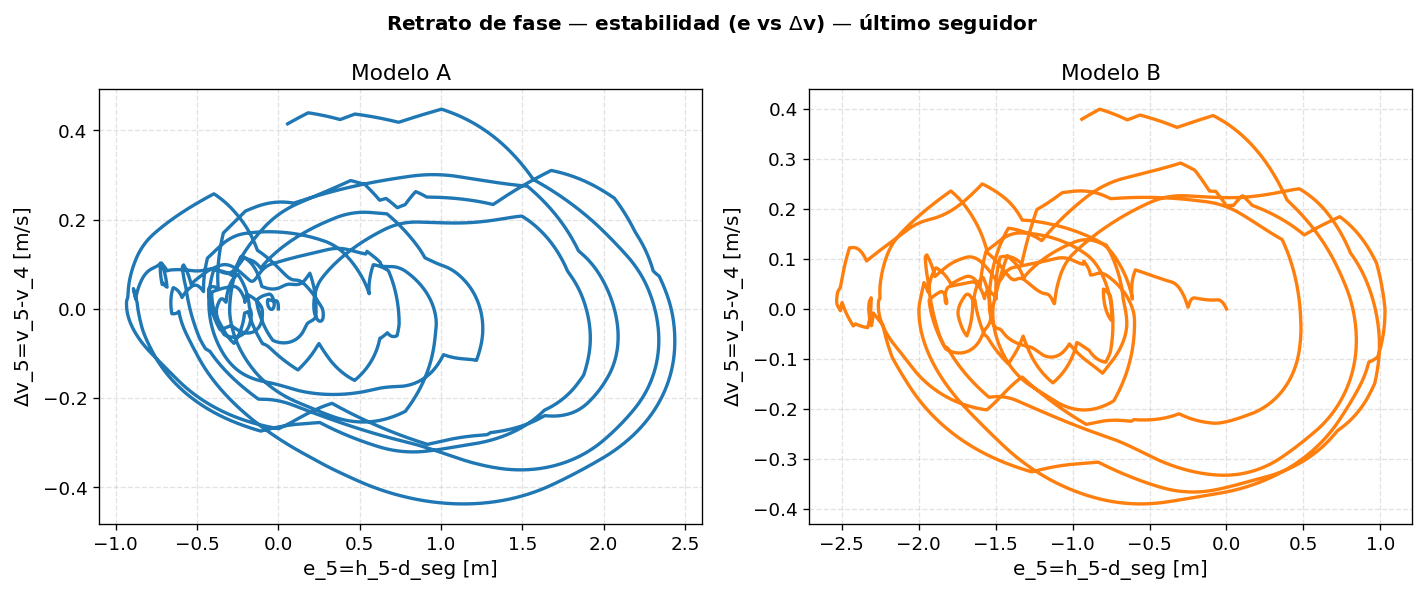

In [24]:
# Retrato de fase (último seguidor)
idx = N-1
fig2, ax2 = plt.subplots(1, 2, figsize=(12, 5))
fig2.suptitle(r'Retrato de fase — estabilidad (e vs $\Delta$v) — último seguidor',
              fontsize=12, fontweight='bold')
ax2[0].plot(eA2[:,idx], dvA2[:,idx], color='tab:blue')
ax2[0].set_xlabel(f'e_{idx+1}=h_{idx+1}-d_seg [m]')
ax2[0].set_ylabel(f'$\Delta$v_{idx+1}=v_{idx+1}-v_{idx} [m/s]')
ax2[0].set_title('Modelo A')
ax2[1].plot(eB2[:,idx], dvB2[:,idx], color='tab:orange')
ax2[1].set_xlabel(f'e_{idx+1}=h_{idx+1}-d_seg [m]')
ax2[1].set_ylabel(fr'$\Delta$v_{idx+1}=v_{idx+1}-v_{idx} [m/s]')
ax2[1].set_title('Modelo B')
plt.tight_layout()
plt.savefig("02_fig_retrato_fase.png", dpi=150, bbox_inches="tight")


---
## 21 --- Resultados: potencia y energia acumulada

La integracion de la potencia instantanea $P_i = F_{real,i}\,v_i$
permite cuantificar el consumo energetico de cada vehiculo.
Se espera que los seguidores consuman menos que el lider
gracias al efecto de reduccion aerodinamica por platooning.

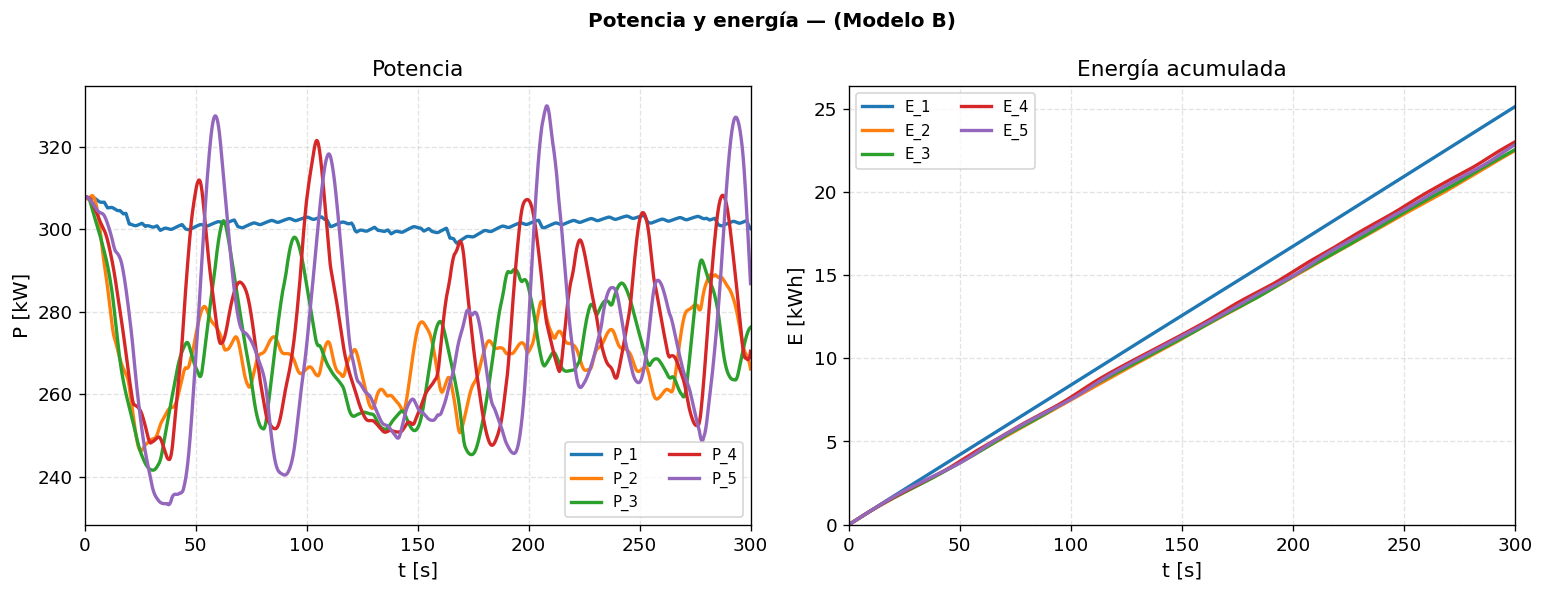

In [25]:
# Potencia y energía (Modelo B)
fig3, ax3 = plt.subplots(1, 2, figsize=(13,5))
fig3.suptitle('Potencia y energía — (Modelo B)', fontsize=12, fontweight='bold')
for i in range(N):
    ax3[0].plot(tB2, PB2[:,i]/1000.0, label=f'P_{i+1}')
    ax3[1].plot(tB2, EB2[:,i]/3.6e6, label=f'E_{i+1}')
ax3[0].set_xlim([0, tf])
ax3[1].set_xlim([0, tf])
ax3[1].set_ylim(0, None)
ax3[0].set_xlabel('t [s]'); ax3[0].set_ylabel('P [kW]'); ax3[0].set_title('Potencia')
ax3[1].set_xlabel('t [s]'); ax3[1].set_ylabel('E [kWh]'); ax3[1].set_title('Energía acumulada')
ax3[0].legend(fontsize=9, ncol=2)
ax3[1].legend(fontsize=9, ncol=2)
plt.tight_layout()
plt.savefig("02_fig_potencia_energia.png", dpi=150, bbox_inches="tight")


---
## 22 --- Conclusiones y Resumen de Seguridad

El análisis del **Caso 2** permitió evaluar cómo ciertos cambios en las condiciones del sistema afectan el comportamiento del flujo vehicular a lo largo del espacio. A partir de la simulación numérica y de la comparación con el caso base, se pudieron identificar algunas tendencias importantes en la evolución de la densidad y el flujo de vehículos.

**Sobre el método numérico.**  
El modelo fue resuelto utilizando el mismo esquema explícito de diferencias finitas empleado en el caso anterior. Este método permitió seguir la evolución temporal de la densidad de vehículos en cada punto de la vía de manera sencilla y clara. Durante las simulaciones se mantuvieron los mismos parámetros de discretización temporal y espacial, lo que permitió comparar directamente los resultados entre ambos escenarios.

**Sobre la evolución de la densidad vehicular.**  
En este segundo escenario se observaron cambios en la forma en que la densidad de vehículos se distribuye a lo largo de la vía. Dependiendo de las condiciones iniciales o de frontera consideradas en el caso, el sistema mostró una reorganización distinta del flujo vehicular con respecto al caso base. En particular, las zonas de mayor densidad generaron perturbaciones que se propagaron a lo largo de la carretera, lo cual es consistente con el comportamiento esperado en modelos macroscópicos de tráfico.

**Sobre el comportamiento del flujo.**  
Los resultados también muestran cómo pequeñas variaciones en las condiciones del sistema pueden modificar la forma en que se transporta la densidad de vehículos. En ciertas regiones del dominio se observó una tendencia hacia la acumulación de vehículos, lo que sugiere el inicio de fenómenos de congestión. Este tipo de comportamiento es característico cuando la densidad del tráfico se aproxima a valores altos en la relación velocidad–densidad utilizada en el modelo.

**Sobre la interpretación del headway de referencia.**  
Durante el análisis del Caso 2 también se observó que el valor elegido para el *headway* de referencia tiene una influencia importante en la viabilidad física del modelo. En particular, cuando se consideran valores de *headway* relativamente pequeños o grandes sin tener en cuenta la velocidad del flujo vehicular, pueden aparecer situaciones poco realistas. Por ejemplo, un *headway* de referencia cercano a 20 m solo sería razonable para velocidades relativamente bajas. A velocidades de circulación más altas, los conductores normalmente mantienen distancias mayores por razones de seguridad, que pueden alcanzar valores del orden de 40 m o más.  

**Interpretación del modelo.**  
Aunque el modelo utilizado es relativamente simple, permite visualizar de manera clara cómo la densidad vehicular evoluciona en el tiempo y el espacio. El Caso 2 resulta útil para entender cómo cambios en las condiciones del sistema pueden generar patrones distintos en el flujo de tráfico, lo cual ayuda a interpretar de forma cualitativa fenómenos como la formación y propagación de ondas de congestión.

Esto sugiere que, aunque el modelo captura adecuadamente la relación básica entre densidad, flujo y velocidad, la elección de ciertos parámetros debe hacerse con cuidado para que los escenarios simulados representen condiciones plausibles de tráfico real.

**Conclusión general.**  
En conjunto, el Caso 2 complementa el análisis realizado en el caso base y muestra que el modelo implementado es capaz de capturar cambios en el comportamiento del flujo vehicular cuando se modifican las condiciones del sistema. Este tipo de análisis permite comprender mejor la sensibilidad del modelo y cómo las ecuaciones de conservación pueden utilizarse para estudiar diferentes escenarios de tráfico de manera simplificada.

In [26]:
def resumen_seguridad(t, h, v, dv, ttc, label):
    print("\n" + "="*72)
    print(f"RESUMEN SEGURIDAD — {label}")
    print("="*72)
    for i in range(1, h.shape[1]):
        h_i = h[:, i]
        v_i = v[:, i]
        ttc_i = ttc[:, i]
        dv_i = dv[:, i]

        hmin = np.nanmin(h_i)
        hmean = np.nanmean(h_i)
        Hmin = np.nanmin(h_i / np.maximum(v_i, EPS))

        ttc_min = np.nanmin(ttc_i)
        # TTC crítico solo cuando hay acercamiento (dv>0)
        mask_app = dv_i > 0
        if np.any(mask_app):
            ttc_app = ttc_i[mask_app]
            p2 = 100.0 * np.mean(ttc_app < 2.0)
            p5 = 100.0 * np.mean(ttc_app < 5.0)
        else:
            p2, p5 = 0.0, 0.0

        print(f"Seguidor {i+1}:")
        print(f"  h_min   = {hmin:8.3f} m | h_mean = {hmean:8.3f} m")
        print(f"  H_min   = {Hmin:8.3f} s")
        print(f"  TTC_min = {ttc_min:8.3f} s")
        print(f"  % (TTC<2s) en acercamiento  = {p2:6.2f} %")
        print(f"  % (TTC<5s) en acercamiento  = {p5:6.2f} %")

resumen_seguridad(tA2, hA2, vA2, dvA2, ttcA2, "Modelo A")
resumen_seguridad(tB2, hB2, vB2, dvB2, ttcB2, "Modelo B")


RESUMEN SEGURIDAD — Modelo A
Seguidor 2:
  h_min   =   19.596 m | h_mean =   20.385 m
  H_min   =    0.900 s
  TTC_min =   95.616 s
  % (TTC<2s) en acercamiento  =   0.00 %
  % (TTC<5s) en acercamiento  =   0.00 %
Seguidor 3:
  h_min   =   19.336 m | h_mean =   20.400 m
  H_min   =    0.896 s
  TTC_min =   92.982 s
  % (TTC<2s) en acercamiento  =   0.00 %
  % (TTC<5s) en acercamiento  =   0.00 %
Seguidor 4:
  h_min   =   19.355 m | h_mean =   20.587 m
  H_min   =    0.901 s
  TTC_min =   78.193 s
  % (TTC<2s) en acercamiento  =   0.00 %
  % (TTC<5s) en acercamiento  =   0.00 %
Seguidor 5:
  h_min   =   19.071 m | h_mean =   20.532 m
  H_min   =    0.888 s
  TTC_min =   46.910 s
  % (TTC<2s) en acercamiento  =   0.00 %
  % (TTC<5s) en acercamiento  =   0.00 %

RESUMEN SEGURIDAD — Modelo B
Seguidor 2:
  h_min   =   18.122 m | h_mean =   19.024 m
  H_min   =    0.832 s
  TTC_min =   95.142 s
  % (TTC<2s) en acercamiento  =   0.00 %
  % (TTC<5s) en acercamiento  =   0.00 %
Seguidor 3:
  h